# Reported Road Collisions in Great Britain, 2025

**DSM050 Data Visualisation - Final Coursework**

## 1. Project Overview

This notebook analyses the Department for Transport's 2025 *Road Safety Open Data collision* dataset. It documents the reproducible workflow used for data acquisition, validation, preprocessing, exploratory visualisation and analysis of five research questions concerning temporal, spatial, road-environment and environmental patterns in reported road collisions across Great Britain.

**The investigation addresses five research questions:**
- **RQ1:** How did the frequency of reported personal-injury road collisions vary over time in Great Britain during 2025?  
- **RQ2:** How did the severity of reported collisions vary according to time of day and day of the week?
- **RQ3:** Where were reported road collisions geographically concentrated across Great Britain in 2025, and how did the spatial distribution differ by collision severity?
- **RQ4:** How did collision frequency and severity vary across different road environments, particularly by speed limit, road type and urban or rural classification?
- **RQ5:** How were reported collision frequency and severity distributed across different light, weather and road-surface conditions?

## Setup 

In [374]:
# Import required libraries and define project paths and helper functions

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebook":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "figures"
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

def save_and_show(fig, path, **kwargs):
    """Save a figure to disk and also render it inline in the notebook."""
    fig.savefig(path, dpi=200, bbox_inches="tight", **kwargs)
    from IPython.display import Image, display
    display(Image(filename=str(path)))
    plt.close(fig)

## 2. Data Acquisition

### 2.1 Data source

The analysis uses the Department for Transport (DfT) *Road Safety Open Data: Collisions, 2025* dataset, which contains police-recorded personal-injury road collisions in Great Britain. The data is provided publicly in STATS19 format. Full discussion of data provenance, validity and limitations is provided in the accompanying PDF report.

### 2.2 Data download and loading

The dataset was loaded directly from the DfT public repository to provide a reproducible acquisition route without manual downloading.

In [375]:
# Direct URL for the final 2025 DfT collision dataset
DATA_URL = (
    "https://data.dft.gov.uk/"
    "road-accidents-safety-data/"
    "dft-road-casualty-statistics-collision-2025.csv"
)

# Load the dataset directly from the Department for Transport
collisions_raw = pd.read_csv(
    DATA_URL,
    low_memory=False
)

print("Dataset loaded successfully.")
print(f"Rows: {collisions_raw.shape[0]:,}")
print(f"Columns: {collisions_raw.shape[1]}")

display(collisions_raw.head())

# Save the exact dataset used in the analysis (required for GitHub repo)
collisions_raw.to_csv(DATA_DIR / "road_collisions_raw_2025.csv", index=False)

Dataset loaded successfully.
Rows: 101,525
Columns: 44


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517H102225,2025,17H102225,449216.0,534979.0,-1.23770,54.70743,17,2,3,...,-1,0,2,1,2,E01033467,7,1,1.0,0.0
1,2025070815222,2025,070815222,363808.0,389192.0,-2.54576,53.39831,7,3,2,...,-1,0,1,2,2,E01012556,3,1,0.0,1.0
2,2025070937984,2025,070937984,362413.0,389071.0,-2.56673,53.39712,7,2,2,...,-1,0,1,3,2,E01012478,7,1,1.0,0.0
3,2025041687395,2025,041687395,368238.0,427802.0,-2.48308,53.74562,4,2,1,...,-1,0,1,1,2,E01012655,7,1,1.0,0.0
4,2025161555094,2025,161555094,510792.0,432167.0,-0.32035,53.77406,16,3,2,...,-1,0,1,1,2,E01012815,3,1,0.0,1.0


### 2.3 Acquisition validation

In [376]:
# Validate that the intended 2025 collision dataset was retrieved

required_columns = {
    "collision_index",
    "collision_year",
    "collision_severity",
    "number_of_vehicles",
    "number_of_casualties",
    "date",
    "day_of_week",
    "time",
    "longitude",
    "latitude",
    "road_type",
    "speed_limit",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "urban_or_rural_area"
}

missing_columns = required_columns.difference(collisions_raw.columns)

validation_dates = pd.to_datetime(
    collisions_raw["date"],
    dayfirst=True,
    errors="coerce"
)

duplicate_ids = collisions_raw["collision_index"].duplicated().sum()

assert not collisions_raw.empty, "The dataset contains no observations."
assert not missing_columns, (
    f"Required variables are missing: {sorted(missing_columns)}"
)
assert collisions_raw["collision_index"].notna().all(), (
    "One or more collision identifiers are missing."
)
assert collisions_raw["collision_year"].eq(2025).all(), (
    "Records outside the 2025 study period were detected."
)
assert validation_dates.notna().all(), (
    "One or more dates could not be parsed."
)
assert validation_dates.between(
    "2025-01-01", "2025-12-31"
).all(), "Dates outside the 2025 study period were detected."
assert duplicate_ids == 0, (
    "Duplicate collision identifiers were detected."
)

print(f"Observations: {len(collisions_raw):,}")
print(f"Variables: {collisions_raw.shape[1]}")
print(f"Required variables present: {len(required_columns)}")
print(
    "Date range:",
    validation_dates.min().date(),
    "to",
    validation_dates.max().date()
)
print(f"Duplicate collision identifiers: {duplicate_ids:,}")
print("Acquisition validation passed.")

Observations: 101,525
Variables: 44
Required variables present: 16
Date range: 2025-01-01 to 2025-12-31
Duplicate collision identifiers: 0
Acquisition validation passed.


## 3. Data Overview and Pre-processing

### 3.1 Initial data inspection

In [377]:
# Summarise the structure of each variable

inspection_summary = pd.DataFrame({
    "dtype": collisions_raw.dtypes.astype(str),
    "non_null": collisions_raw.notna().sum(),
    "missing": collisions_raw.isna().sum(),
    "unique_values": collisions_raw.nunique(dropna=True)
})

inspection_summary["non_null_pct"] = (
    inspection_summary["non_null"] / len(collisions_raw) * 100
).round(4)

display(inspection_summary)

,dtype,non_null,missing,unique_values,non_null_pct
collision_index,str,101525,0,101525,100.000
collision_year,int64,101525,0,1,100.000
collision_ref_no,str,101525,0,101525,100.000
location_easting_osgr,float64,101523,2,83236,99.998
location_northing_osgr,float64,101523,2,83768,99.998
longitude,float64,101523,2,88044,99.998
latitude,float64,101523,2,82164,99.998
police_force,int64,101525,0,44,100.000
collision_severity,int64,101525,0,3,100.000
number_of_vehicles,int64,101525,0,13,100.000


### 3.2 Variable selection and definitions

The raw dataset contains 44 variables, but only those required to address the research questions were retained. The working subset covers collision identification, severity, temporal information, geographical location, road environment and environmental conditions. `collision_year` was excluded because all observations were validated as 2025 records, while latitude and longitude were retained for the planned spatial analysis. Categorical variables were initially preserved in their original coded form.

In [378]:
# Select the variables required for the research questions and create the working dataset

analysis_variables = [
    # Identifier
    "collision_index",

    # Collision outcome
    "collision_severity",
    "number_of_vehicles",
    "number_of_casualties",

    # Temporal variables
    "date",
    "day_of_week",
    "time",

    # Spatial variables
    "longitude",
    "latitude",

    # Road environment
    "road_type",
    "speed_limit",
    "urban_or_rural_area",

    # Environmental conditions
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions"
]

missing_analysis_variables = [
    column
    for column in analysis_variables
    if column not in collisions_raw.columns
]

assert not missing_analysis_variables, (
    f"Selected variables are missing: {missing_analysis_variables}"
)

collisions_selected = collisions_raw[analysis_variables].copy()

print(f"Raw variables: {collisions_raw.shape[1]}")
print(f"Selected variables: {collisions_selected.shape[1]}")
print(f"Excluded variables: {collisions_raw.shape[1] - collisions_selected.shape[1]}")
print(f"Observations retained: {len(collisions_selected):,}")

# Save the selected variables used for subsequent analysis
collisions_selected.to_csv(DATA_DIR / "road_collisions_selected_2025.csv", index=False)

Raw variables: 44
Selected variables: 15
Excluded variables: 29
Observations retained: 101,525


In [379]:
# Document the analytical role and definition of each selected variable

variable_definitions = pd.DataFrame({
    "Variable": [
        "collision_index",
        "collision_severity",
        "number_of_vehicles",
        "number_of_casualties",
        "date",
        "day_of_week",
        "time",
        "longitude",
        "latitude",
        "road_type",
        "speed_limit",
        "urban_or_rural_area",
        "light_conditions",
        "weather_conditions",
        "road_surface_conditions"
    ],
    "Analytical role": [
        "Identifier",
        "Outcome",
        "Context",
        "Context",
        "Temporal",
        "Temporal",
        "Temporal",
        "Spatial",
        "Spatial",
        "Road environment",
        "Road environment",
        "Road environment",
        "Environmental",
        "Environmental",
        "Environmental"
    ],
    "Definition": [
        "Unique identifier for each reported collision",
        "Recorded severity of the collision, determined by the most severely injured casualty",
        "Number of vehicles involved in the collision",
        "Number of casualties resulting from the collision",
        "Date on which the collision occurred",
        "Coded day of the week on which the collision occurred",
        "Recorded time of the collision",
        "Longitude of the reported collision location",
        "Latitude of the reported collision location",
        "Coded classification of the road configuration",
        "Recorded speed limit of the road",
        "Coded urban or rural classification of the collision location",
        "Coded lighting conditions at the time of the collision",
        "Coded weather conditions at the time of the collision",
        "Coded road-surface conditions at the time of the collision"
    ],
    "Research question": [
        "RQ1–RQ5",
        "RQ2–RQ5",
        "Supporting",
        "Supporting",
        "RQ1",
        "RQ1, RQ2",
        "RQ1, RQ2",
        "RQ3",
        "RQ3",
        "RQ4",
        "RQ4",
        "RQ4",
        "RQ5",
        "RQ5",
        "RQ5"
    ]
})

display(variable_definitions)

,Variable,Analytical role,Definition,Research question
0,collision_index,Identifier,Unique identifier for each reported collision,RQ1–RQ5
1,collision_severity,Outcome,"Recorded severity of the collision, determined...",RQ2–RQ5
2,number_of_vehicles,Context,Number of vehicles involved in the collision,Supporting
3,number_of_casualties,Context,Number of casualties resulting from the collision,Supporting
4,date,Temporal,Date on which the collision occurred,RQ1
5,day_of_week,Temporal,Coded day of the week on which the collision o...,"RQ1, RQ2"
6,time,Temporal,Recorded time of the collision,"RQ1, RQ2"
7,longitude,Spatial,Longitude of the reported collision location,RQ3
8,latitude,Spatial,Latitude of the reported collision location,RQ3
9,road_type,Road environment,Coded classification of the road configuration,RQ4


In [380]:
# Inspect observed codes for categorical variables before decoding

coded_variables = [
    "collision_severity",
    "day_of_week",
    "road_type",
    "urban_or_rural_area",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions"
]

code_overview = pd.DataFrame({
    "variable": coded_variables,
    "unique_values": [
        collisions_selected[column].nunique(dropna=True)
        for column in coded_variables
    ],
    "observed_codes": [
        sorted(collisions_selected[column].dropna().unique().tolist())
        for column in coded_variables
    ]
})

display(code_overview)

,variable,unique_values,observed_codes
0,collision_severity,3,"[1, 2, 3]"
1,day_of_week,7,"[1, 2, 3, 4, 5, 6, 7]"
2,road_type,6,"[1, 2, 3, 6, 7, 9]"
3,urban_or_rural_area,3,"[1, 2, 3]"
4,light_conditions,6,"[-1, 1, 4, 5, 6, 7]"
5,weather_conditions,9,"[1, 2, 3, 4, 5, 6, 7, 8, 9]"
6,road_surface_conditions,7,"[-1, 1, 2, 3, 4, 5, 9]"


### 3.3 Missing and erroneous data

The selected variables were assessed for conventional missing values, duplicate observations, invalid temporal values, implausible numerical ranges and coded missing or unknown categories. Coded missingness was checked separately because several STATS19 variables use numerical values for unknown or unresolved categories rather than `NaN`.

In [381]:
# Assess conventional missing values in the selected variables

missing_summary = pd.DataFrame({
    "missing_count": collisions_selected.isna().sum(),
    "missing_pct": (
        collisions_selected.isna().mean() * 100
    ).round(4)
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
]

display(missing_summary)

print(
    f"Rows containing at least one conventional missing value: "
    f"{collisions_selected.isna().any(axis=1).sum():,}"
)

,missing_count,missing_pct
longitude,2,0.002
latitude,2,0.002


Rows containing at least one conventional missing value: 2


In [382]:
# Check structural integrity and temporal validity

duplicate_rows = collisions_selected.duplicated().sum()
duplicate_ids = collisions_selected["collision_index"].duplicated().sum()

date_check = pd.to_datetime(
    collisions_selected["date"],
    dayfirst=True,
    errors="coerce"
)

time_check = pd.to_datetime(
    collisions_selected["time"],
    format="%H:%M",
    errors="coerce"
)

print(f"Exact duplicate rows: {duplicate_rows:,}")
print(f"Duplicate collision identifiers: {duplicate_ids:,}")
print(f"Unparseable dates: {date_check.isna().sum():,}")
print(f"Unparseable times: {time_check.isna().sum():,}")
print(
    f"Observed date range: "
    f"{date_check.min().date()} to {date_check.max().date()}"
)

Exact duplicate rows: 0
Duplicate collision identifiers: 0
Unparseable dates: 0
Unparseable times: 0
Observed date range: 2025-01-01 to 2025-12-31


In [383]:
# Inspect ranges of numerical and spatial variables
range_summary = collisions_selected[
    [
        "number_of_vehicles",
        "number_of_casualties",
        "speed_limit",
        "longitude",
        "latitude"
    ]
].agg(["min", "median", "max"]).T

display(range_summary)

# Check values that would be structurally invalid
invalid_checks = {
    "Vehicles below 1": (
        collisions_selected["number_of_vehicles"] < 1
    ).sum(),

    "Casualties below 1": (
        collisions_selected["number_of_casualties"] < 1
    ).sum(),

    "Invalid longitude": (
        collisions_selected["longitude"].notna()
        & ~collisions_selected["longitude"].between(-180, 180)
    ).sum(),

    "Invalid latitude": (
        collisions_selected["latitude"].notna()
        & ~collisions_selected["latitude"].between(-90, 90)
    ).sum(),

    "Non-positive speed limit": (
    collisions_selected["speed_limit"] <= 0
    ).sum()
}

pd.DataFrame.from_dict(
    invalid_checks,
    orient="index",
    columns=["count"]
)

,min,median,max
number_of_vehicles,1.00000,2.00000,17.00000
number_of_casualties,1.00000,1.00000,142.00000
speed_limit,20.00000,30.00000,70.00000
longitude,-7.41772,-1.13891,1.75559
latitude,49.91253,51.88864,60.34525


,count
Vehicles below 1,0
Casualties below 1,0
Invalid longitude,0
Invalid latitude,0
Non-positive speed limit,0


In [384]:
# Codes representing missing, unknown or unresolved categories according to the DfT coding scheme

coded_quality_values = {
    "road_type": [9],
    "urban_or_rural_area": [3],
    "light_conditions": [-1],
    "weather_conditions": [9],
    "road_surface_conditions": [-1, 9]
}

coded_quality_summary = []

for variable, codes in coded_quality_values.items():
    for code in codes:
        count = (collisions_selected[variable] == code).sum()
        percentage = count / len(collisions_selected) * 100

        coded_quality_summary.append({
            "variable": variable,
            "code": code,
            "count": count,
            "percentage": round(percentage, 3)
        })

coded_quality_summary = pd.DataFrame(coded_quality_summary)

display(coded_quality_summary)

,variable,code,count,percentage
0,road_type,9,1953,1.924
1,urban_or_rural_area,3,4,0.004
2,light_conditions,-1,16,0.016
3,weather_conditions,9,2385,2.349
4,road_surface_conditions,-1,634,0.624
5,road_surface_conditions,9,1342,1.322


### 3.4 Data cleaning

Cleaning was designed to preserve as much validated source data as possible. The two observations without geographical coordinates were removed because location is required for the spatial analysis and the missing coordinates could not be reliably imputed. STATS19 categorical codes were translated using the DfT data guide, while unknown or unresolved categories were retained explicitly rather than deleting otherwise valid observations.

In [385]:
# Create the cleaning dataset and remove records without usable geographical coordinates
collisions_clean = collisions_selected.copy()

rows_before = len(collisions_clean)

# Remove records without usable geographical coordinates
missing_coordinates = (
    collisions_clean[["longitude", "latitude"]]
    .isna()
    .any(axis=1)
)

coordinate_rows_removed = missing_coordinates.sum()

collisions_clean = (
    collisions_clean.loc[~missing_coordinates]
    .copy()
    .reset_index(drop=True)
)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows removed for missing coordinates: {coordinate_rows_removed:,}")
print(f"Rows remaining: {len(collisions_clean):,}")
print(
    f"Percentage of records removed: "
    f"{coordinate_rows_removed / rows_before * 100:.4f}%"
)

Rows before cleaning: 101,525
Rows removed for missing coordinates: 2
Rows remaining: 101,523
Percentage of records removed: 0.0020%


In [386]:
# Convert temporal variables to appropriate data types

collisions_clean["date"] = pd.to_datetime(
    collisions_clean["date"],
    dayfirst=True
)

collisions_clean["time"] = pd.to_datetime(
    collisions_clean["time"],
    format="%H:%M"
).dt.time

In [387]:
# Define STATS19 categorical mappings using the DfT data guide

category_maps = {
    "collision_severity": {
        1: "Fatal",
        2: "Serious",
        3: "Slight"
    },

    "day_of_week": {
        1: "Sunday",
        2: "Monday",
        3: "Tuesday",
        4: "Wednesday",
        5: "Thursday",
        6: "Friday",
        7: "Saturday"
    },

    "road_type": {
        1: "Roundabout",
        2: "One way street",
        3: "Dual carriageway",
        6: "Single carriageway",
        7: "Slip road",
        9: "Unknown",
        12: "One way street / slip road",
        -1: "Data missing or out of range"
    },

    "urban_or_rural_area": {
        1: "Urban",
        2: "Rural",
        3: "Unallocated",
        -1: "Data missing or out of range"
    },

    "light_conditions": {
        1: "Daylight",
        4: "Darkness - lights lit",
        5: "Darkness - lights unlit",
        6: "Darkness - no lighting",
        7: "Darkness - lighting unknown",
        -1: "Data missing or out of range"
    },

    "weather_conditions": {
        1: "Fine no high winds",
        2: "Raining no high winds",
        3: "Snowing no high winds",
        4: "Fine + high winds",
        5: "Raining + high winds",
        6: "Snowing + high winds",
        7: "Fog or mist",
        8: "Other",
        9: "Unknown",
        -1: "Data missing or out of range"
    },

    "road_surface_conditions": {
        1: "Dry",
        2: "Wet or damp",
        3: "Snow",
        4: "Frost or ice",
        5: "Flood over 3cm deep",
        6: "Oil or diesel",
        7: "Mud",
        9: "Unknown",
        -1: "Data missing or out of range"
    }
}

In [388]:
# Validate and decode STATS19 categorical variables

for variable, mapping in category_maps.items():
    observed_codes = set(
        collisions_clean[variable]
        .dropna()
        .unique()
    )

    unmapped_codes = observed_codes.difference(mapping.keys())

    assert not unmapped_codes, (
        f"Unmapped codes found in {variable}: "
        f"{sorted(unmapped_codes)}"
    )

for variable, mapping in category_maps.items():
    collisions_clean[variable] = (
        collisions_clean[variable]
        .map(mapping)
    )

print("Categorical variables validated and decoded successfully.")

Categorical variables validated and decoded successfully.


In [389]:
# Define meaningful category orders for later analysis and plotting

severity_order = [
    "Fatal",
    "Serious",
    "Slight"
]

day_order = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

collisions_clean["collision_severity"] = pd.Categorical(
    collisions_clean["collision_severity"],
    categories=severity_order,
    ordered=True
)

collisions_clean["day_of_week"] = pd.Categorical(
    collisions_clean["day_of_week"],
    categories=day_order,
    ordered=True
)

In [390]:
# Validate the cleaned dataset

print(f"Clean dataset shape: {collisions_clean.shape}")

print(
    "Remaining missing coordinates:",
    collisions_clean[
        ["longitude", "latitude"]
    ].isna().any(axis=1).sum()
)

print(
    "Duplicate collision identifiers:",
    collisions_clean["collision_index"].duplicated().sum()
)

print(
    "Missing values introduced during category decoding:",
    collisions_clean[
        list(category_maps.keys())
    ].isna().sum().sum()
)

print(
    "Date range:",
    collisions_clean["date"].min().date(),
    "to",
    collisions_clean["date"].max().date()
)

# Save the exact dataset used in the analysis (required for GitHub repo)
collisions_clean.to_csv(DATA_DIR / "road_collisions_clean_2025.csv", index=False)

Clean dataset shape: (101523, 15)
Remaining missing coordinates: 0
Duplicate collision identifiers: 0
Missing values introduced during category decoding: 0
Date range: 2025-01-01 to 2025-12-31


### 3.5 Feature engineering

Feature engineering was limited to variables required for the planned temporal and severity analyses.

In [391]:
# Derive temporal and severity features required for the analysis
collisions_engineered = collisions_clean.copy()

# Calendar month
collisions_engineered["month"] = (
    collisions_engineered["date"].dt.month
)

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

collisions_engineered["month_name"] = pd.Categorical(
    collisions_engineered["date"].dt.month_name(),
    categories=month_order,
    ordered=True
)

# Hour of collision
collisions_engineered["hour"] = (
    collisions_engineered["time"]
    .apply(lambda x: x.hour)
)

# Binary severity indicator
collisions_engineered["is_fatal_or_serious"] = (
    collisions_engineered["collision_severity"]
    .isin(["Fatal", "Serious"])
)

In [392]:
# Validate the engineered features

engineered_variables = [
    "month",
    "month_name",
    "hour",
    "is_fatal_or_serious"
]

print(f"Rows: {len(collisions_engineered):,}")
print(f"Columns: {collisions_engineered.shape[1]}")

display(
    collisions_engineered[
        engineered_variables
    ].isna().sum().to_frame("missing")
)

print(
    f"Hour range: "
    f"{collisions_engineered['hour'].min()}–"
    f"{collisions_engineered['hour'].max()}"
)

assert len(collisions_engineered) == len(collisions_clean)

Rows: 101,523
Columns: 19


,missing
month,0
month_name,0
hour,0
is_fatal_or_serious,0


Hour range: 0–23


### 3.6 Final analytical dataset

In [393]:
# Create the final analytical dataset
collisions = collisions_engineered.copy()

print(f"Final observations: {collisions.shape[0]:,}")
print(f"Final variables: {collisions.shape[1]}")

# Save the exact dataset used in the analysis (required for GitHub repo)
collisions.to_csv(DATA_DIR / "road_collisions_final_2025.csv", index=False)

Final observations: 101,523
Final variables: 19


In [394]:
# Validate the final analytical dataset

assert len(collisions) == len(collisions_clean), (
    "Unexpected number of observations in the final dataset."
)

assert collisions["collision_index"].is_unique, (
    "Duplicate collision identifiers are present."
)

assert collisions.isna().sum().sum() == 0, (
    "Unexpected conventional missing values remain."
)

assert collisions["date"].between(
    "2025-01-01",
    "2025-12-31"
).all(), (
    "Dates outside the study period are present."
)

assert collisions["month"].between(1, 12).all(), (
    "Invalid month values are present."
)

assert collisions["hour"].between(0, 23).all(), (
    "Invalid hour values are present."
)

print("Final analytical dataset validation passed.")

Final analytical dataset validation passed.


In [395]:
# Map each research question to the variables used in the analysis

rq_variable_map = pd.DataFrame({
    "Research question": [
        "RQ1 — Temporal patterns",
        "RQ2 — Temporal patterns in severity",
        "RQ3 — Spatial distribution and severity",
        "RQ4 — Road environment and collision outcomes",
        "RQ5 — Environmental conditions and collision outcomes"
    ],
    "Principal variables": [
        "date, month, month_name",
        "day_of_week, hour, collision_severity, is_fatal_or_serious",
        "longitude, latitude, collision_severity, is_fatal_or_serious",
        "road_type, speed_limit, urban_or_rural_area, collision_severity, is_fatal_or_serious",
        "light_conditions, weather_conditions, road_surface_conditions, collision_severity, is_fatal_or_serious"
    ]
})

display(rq_variable_map)

,Research question,Principal variables
0,RQ1 — Temporal patterns,"date, month, month_name"
1,RQ2 — Temporal patterns in severity,"day_of_week, hour, collision_severity, is_fata..."
2,RQ3 — Spatial distribution and severity,"longitude, latitude, collision_severity, is_fa..."
3,RQ4 — Road environment and collision outcomes,"road_type, speed_limit, urban_or_rural_area, c..."
4,RQ5 — Environmental conditions and collision o...,"light_conditions, weather_conditions, road_sur..."


### 3.7 Summary statistics

Summary statistics provide a descriptive overview of the final analytical dataset before visual analysis.

In [396]:
# Descriptive statistics for collision-level count variables

numerical_summary = (
    collisions[
        ["number_of_vehicles", "number_of_casualties"]
    ]
    .describe(
        percentiles=[0.25, 0.5, 0.75]
    )
    .T
    .rename(columns={
        "count": "n",
        "mean": "mean",
        "std": "std",
        "min": "min",
        "25%": "Q1",
        "50%": "median",
        "75%": "Q3",
        "max": "max"
    })
)

numerical_summary = numerical_summary[
    ["n", "mean", "std", "min", "Q1", "median", "Q3", "max"]
].round(2)

display(numerical_summary)

,n,mean,std,min,Q1,median,Q3,max
number_of_vehicles,101523.0,1.81,0.69,1.0,1.0,2.0,2.0,17.0
number_of_casualties,101523.0,1.26,0.82,1.0,1.0,1.0,1.0,142.0


In [397]:
# Summarise recorded collision severity

severity_summary = (
    collisions["collision_severity"]
    .value_counts(sort=False)
    .rename("count")
    .to_frame()
)

severity_summary["percentage"] = (
    severity_summary["count"]
    / len(collisions)
    * 100
).round(2)

display(severity_summary)

fatal_serious_count = (
    collisions["is_fatal_or_serious"].sum()
)

fatal_serious_pct = (
    collisions["is_fatal_or_serious"].mean()
    * 100
)

print(
    f"Fatal or serious collisions: "
    f"{fatal_serious_count:,} "
    f"({fatal_serious_pct:.2f}%)"
)

,count,percentage
collision_severity,,
Fatal,1453,1.43
Serious,25190,24.81
Slight,74880,73.76


Fatal or serious collisions: 26,643 (26.24%)


In [398]:
# Summarise the overall temporal distribution

daily_counts = (
    collisions
    .groupby("date", observed=False)
    .size()
)

temporal_summary = pd.DataFrame({
    "Statistic": [
        "Total collisions",
        "Days represented",
        "Mean collisions per day",
        "Median collisions per day",
        "Minimum collisions in a day",
        "Maximum collisions in a day"
    ],
    "Value": [
        len(collisions),
        daily_counts.index.nunique(),
        round(daily_counts.mean(), 2),
        round(daily_counts.median(), 2),
        daily_counts.min(),
        daily_counts.max()
    ]
})

display(temporal_summary)

,Statistic,Value
0,Total collisions,101523.00
1,Days represented,365.00
2,Mean collisions per day,278.15
3,Median collisions per day,279.00
4,Minimum collisions in a day,120.00
5,Maximum collisions in a day,412.00


In [399]:
# Summarise the most frequently recorded category for the principal contextual variables

context_variables = [
    "road_type",
    "speed_limit",
    "urban_or_rural_area",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions"
]

context_summary = []

for variable in context_variables:
    counts = collisions[variable].value_counts(dropna=False)

    most_common = counts.index[0]
    count = counts.iloc[0]
    percentage = count / len(collisions) * 100

    context_summary.append({
        "variable": variable,
        "most_common_category": most_common,
        "count": count,
        "percentage": round(percentage, 2)
    })

context_summary = pd.DataFrame(context_summary)

display(context_summary)

,variable,most_common_category,count,percentage
0,road_type,Single carriageway,74149,73.04
1,speed_limit,30,49673,48.93
2,urban_or_rural_area,Urban,67148,66.14
3,light_conditions,Daylight,72812,71.72
4,weather_conditions,Fine no high winds,83404,82.15
5,road_surface_conditions,Dry,75678,74.54


## 4. Exploratory Visualisation

### 4.1 Temporal distribution

Mean daily collision counts were examined by month to provide broad temporal context before the research questions consider shorter-term patterns. Daily means were used rather than raw monthly totals to account for differences in month length.

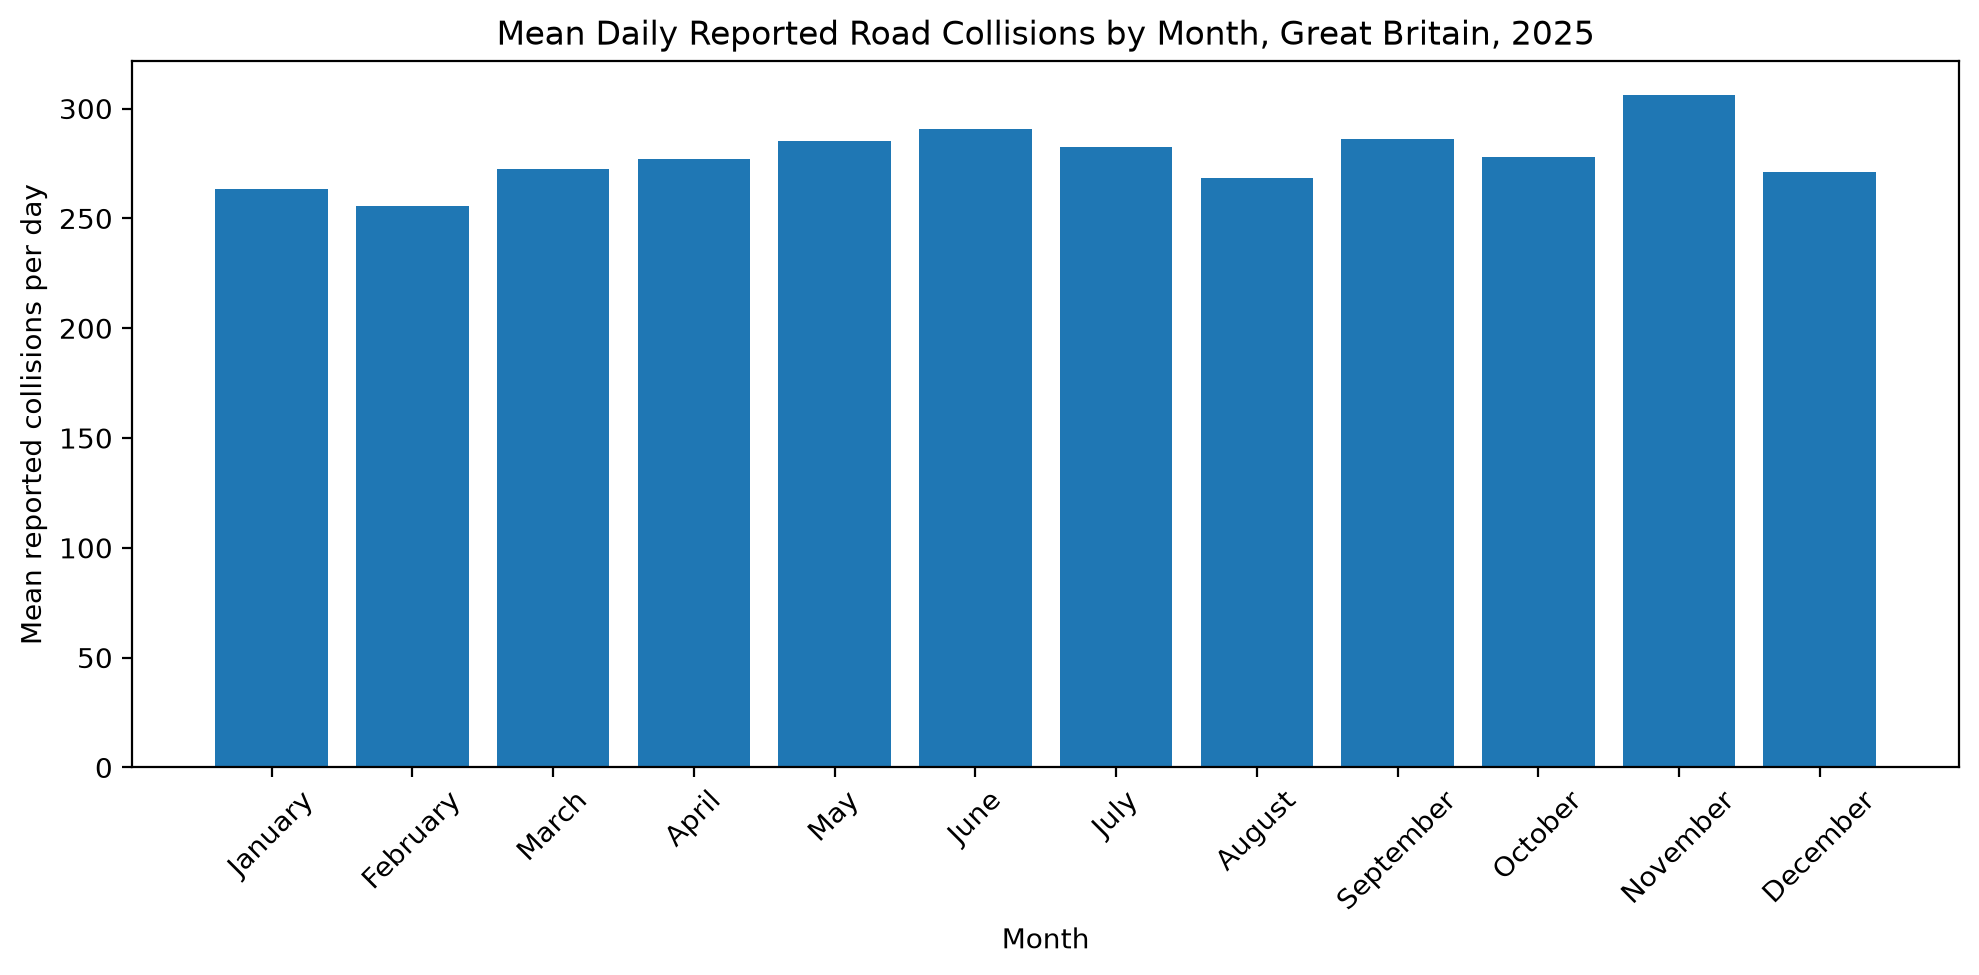

In [400]:
# Calculate mean daily collision count for each month

daily_collision_counts = (
    collisions
    .groupby("date")
    .size()
    .rename("collisions")
    .reset_index()
)

daily_collision_counts["month_name"] = pd.Categorical(
    daily_collision_counts["date"].dt.month_name(),
    categories=month_order,
    ordered=True
)

monthly_daily_mean = (
    daily_collision_counts
    .groupby("month_name", observed=False)["collisions"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    monthly_daily_mean.index,
    monthly_daily_mean.values
)

ax.set_title(
    "Mean Daily Reported Road Collisions by Month, Great Britain, 2025"
)
ax.set_xlabel("Month")
ax.set_ylabel("Mean reported collisions per day")

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

save_and_show(fig, FIG_DIR / "monthly_daily_mean.png")

### 4.2 Collision severity and contextual conditions

Recorded collision severity and the dominant road-environment and environmental categories were summarised to provide context for the later multivariate analysis.

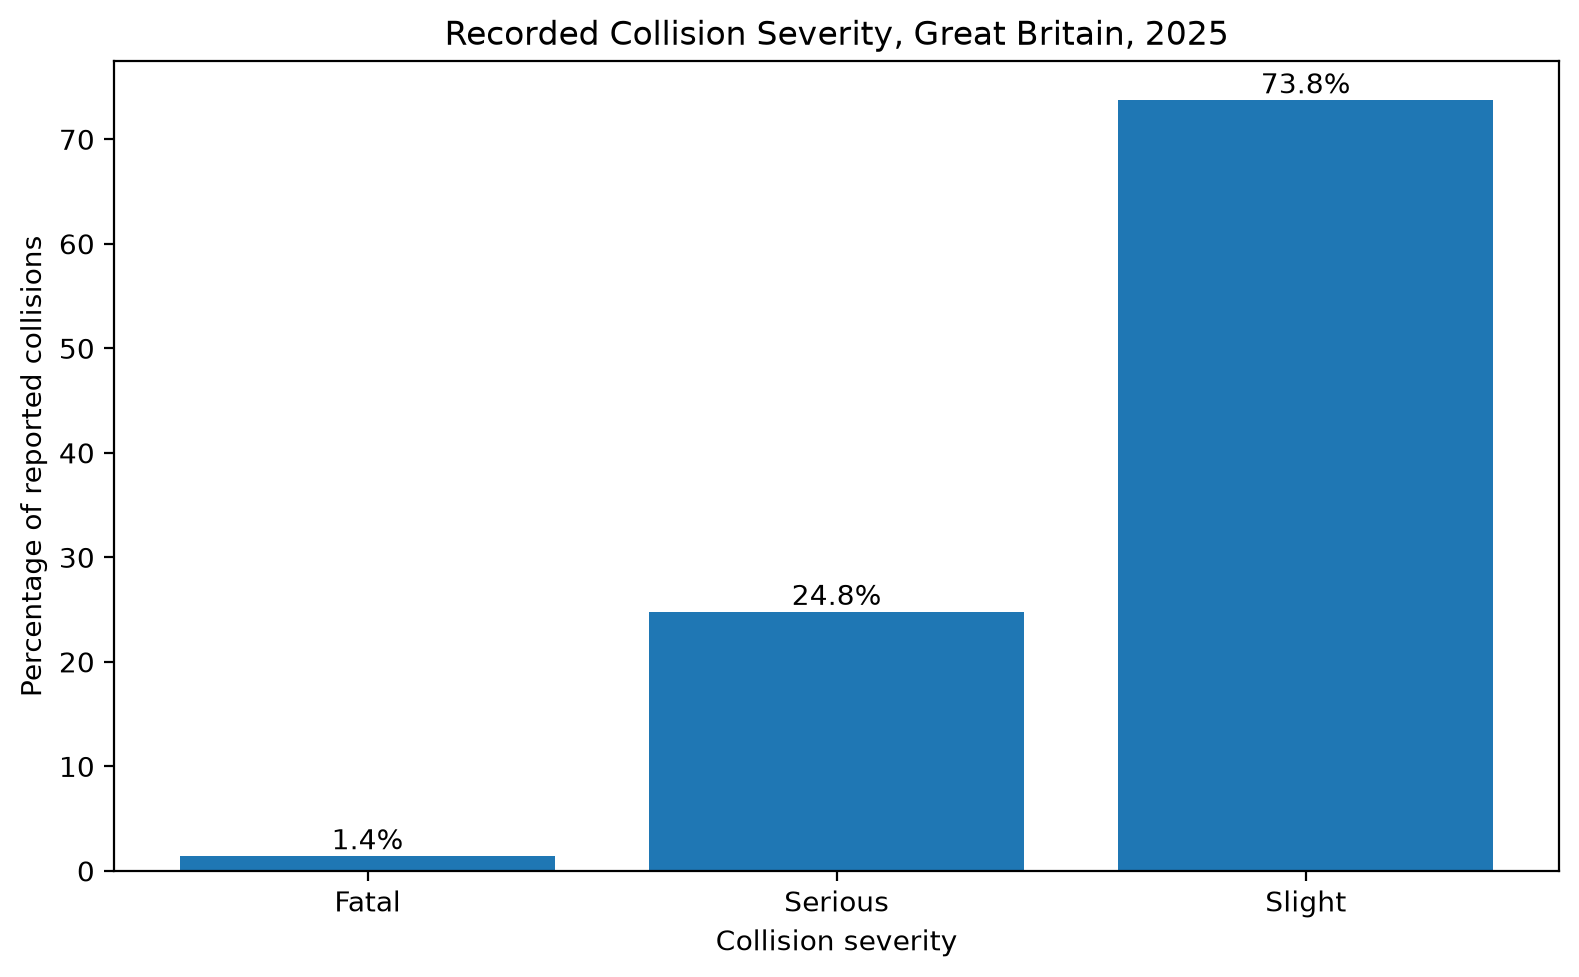

In [401]:
# Calculate the distribution of recorded collision severity

severity_plot = (
    collisions["collision_severity"]
    .value_counts(sort=False)
    .rename("count")
    .to_frame()
)

severity_plot["percentage"] = (
    severity_plot["count"] / len(collisions) * 100
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    severity_plot.index.astype(str),
    severity_plot["percentage"]
)

ax.set_title("Recorded Collision Severity, Great Britain, 2025")
ax.set_xlabel("Collision severity")
ax.set_ylabel("Percentage of reported collisions")

for bar, value in zip(bars, severity_plot["percentage"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

save_and_show(fig, FIG_DIR / "recorded_severity.png")

In [402]:
# Summarise the dominant road and environmental categories

context_overview = pd.DataFrame({
    "Variable": [
        "Road type",
        "Speed limit",
        "Urban/rural area",
        "Light conditions",
        "Weather conditions",
        "Road-surface conditions"
    ],
    "Most common category": [
        collisions["road_type"].value_counts().idxmax(),
        collisions["speed_limit"].value_counts().idxmax(),
        collisions["urban_or_rural_area"].value_counts().idxmax(),
        collisions["light_conditions"].value_counts().idxmax(),
        collisions["weather_conditions"].value_counts().idxmax(),
        collisions["road_surface_conditions"].value_counts().idxmax()
    ],
    "Percentage": [
        collisions["road_type"].value_counts(normalize=True).max() * 100,
        collisions["speed_limit"].value_counts(normalize=True).max() * 100,
        collisions["urban_or_rural_area"].value_counts(normalize=True).max() * 100,
        collisions["light_conditions"].value_counts(normalize=True).max() * 100,
        collisions["weather_conditions"].value_counts(normalize=True).max() * 100,
        collisions["road_surface_conditions"].value_counts(normalize=True).max() * 100
    ]
})

context_overview["Percentage"] = (
    context_overview["Percentage"].round(2)
)

display(context_overview)

,Variable,Most common category,Percentage
0,Road type,Single carriageway,73.04
1,Speed limit,30,48.93
2,Urban/rural area,Urban,66.14
3,Light conditions,Daylight,71.72
4,Weather conditions,Fine no high winds,82.15
5,Road-surface conditions,Dry,74.54


### 4.3 Spatial distribution

The geographical distribution of reported collisions was explored using longitude and latitude coordinates. Because the dataset contains more than 100,000 locations, hexagonal spatial aggregation was used to reduce overplotting and reveal areas of greater collision concentration.

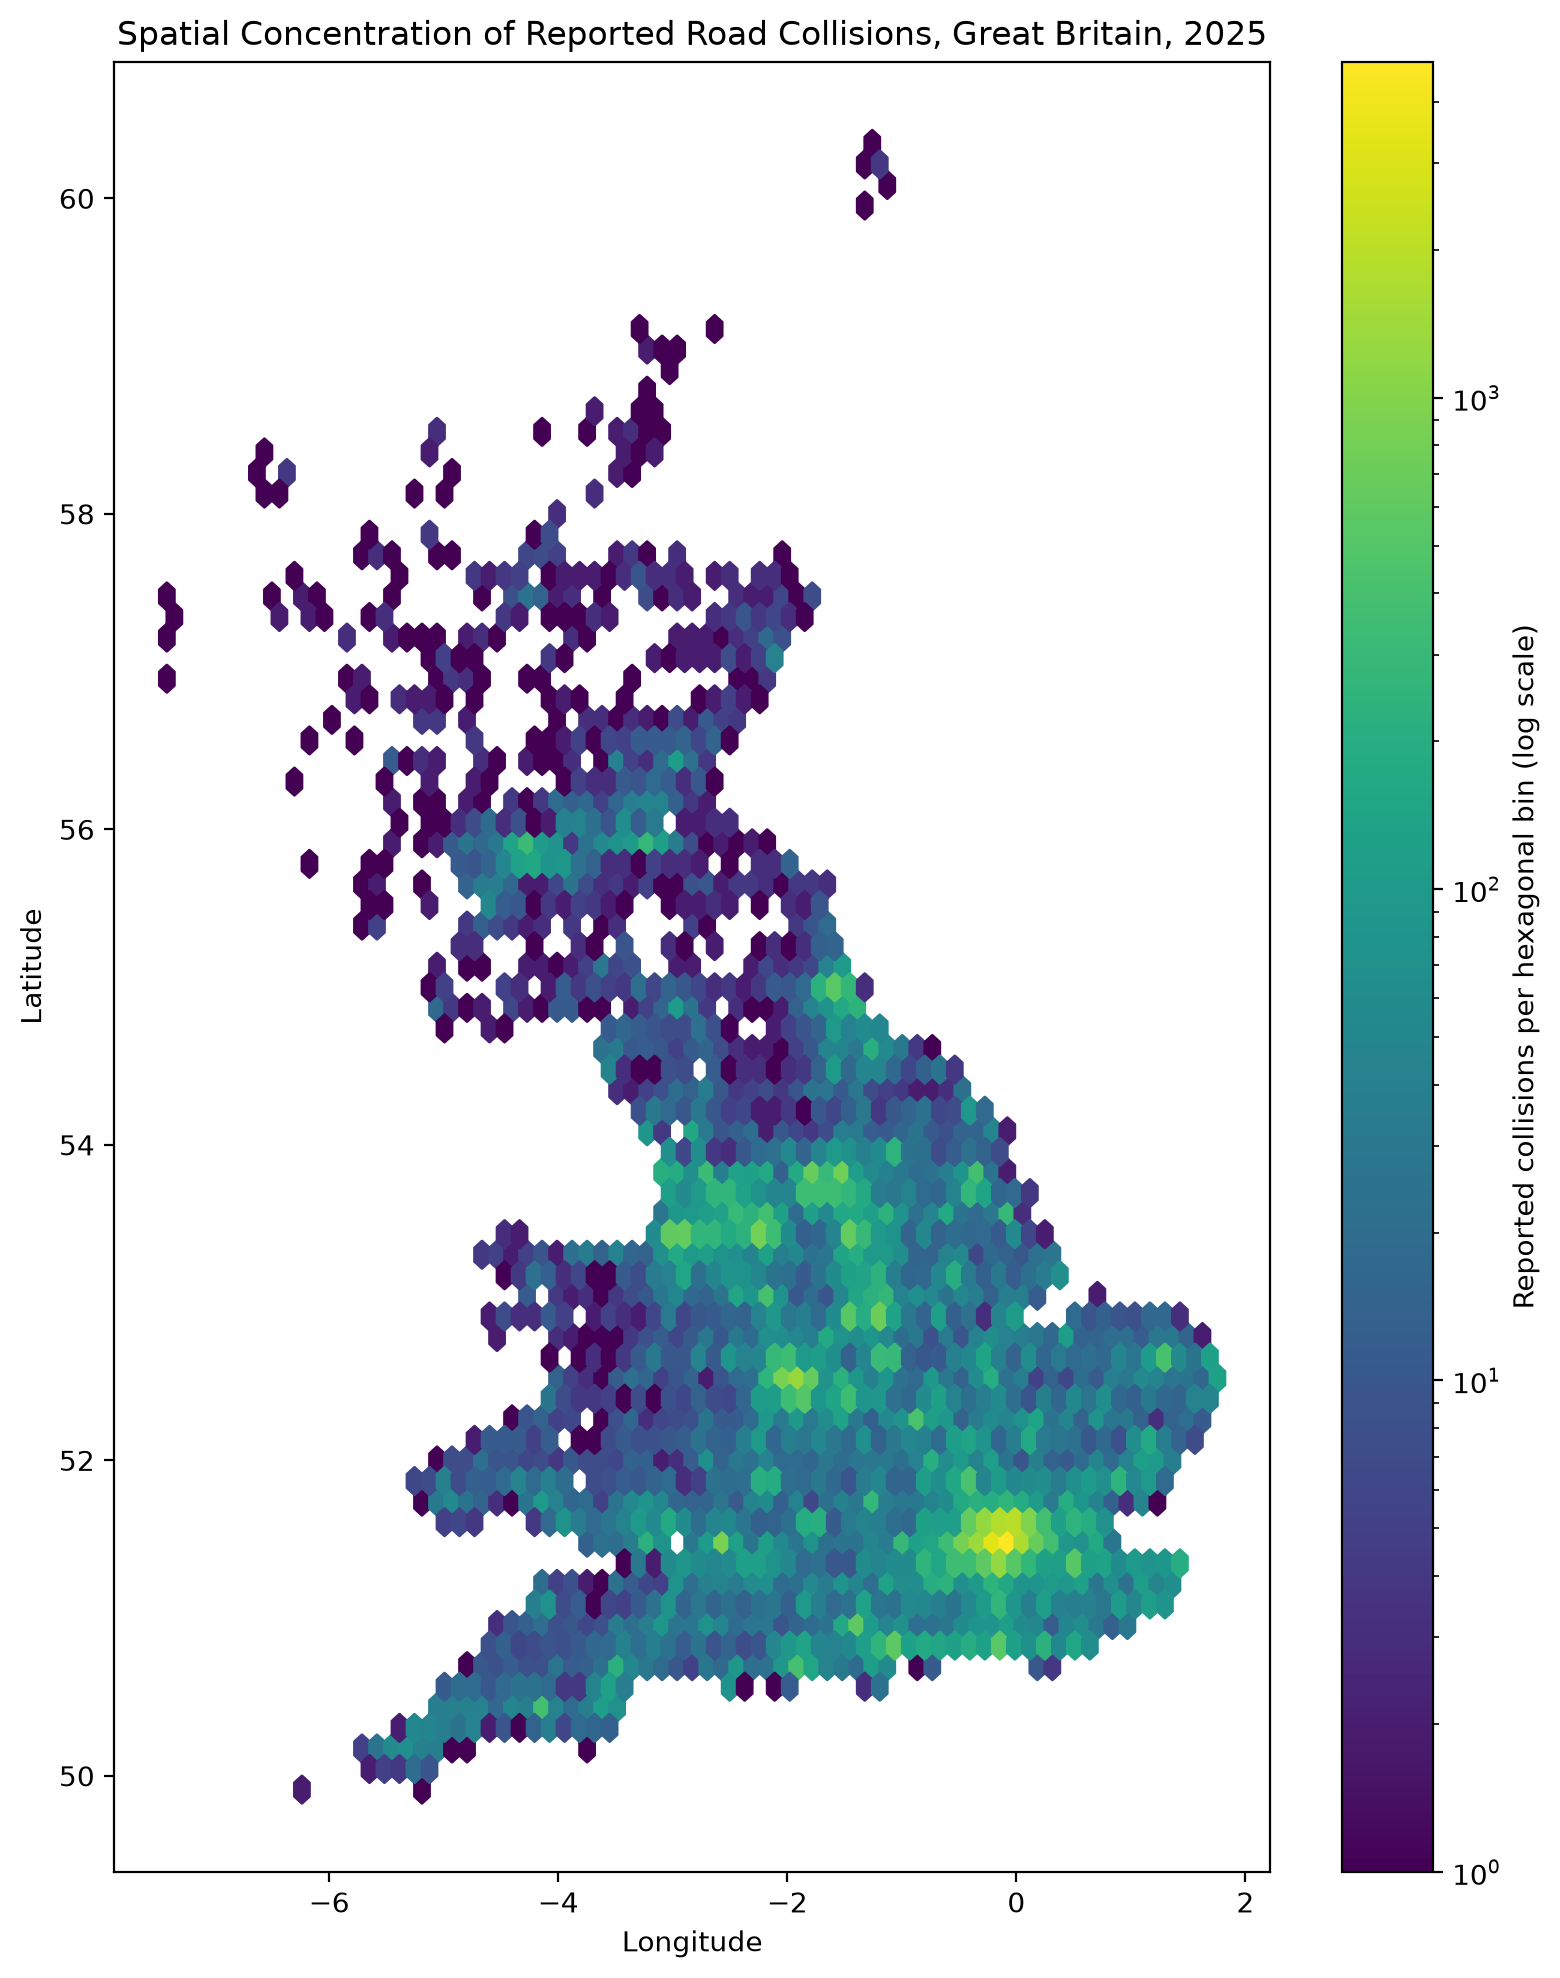

In [403]:
# Aggregate dense collision locations into hexagonal spatial bins

fig, ax = plt.subplots(figsize=(8, 10))

hex_plot = ax.hexbin(
    collisions["longitude"],
    collisions["latitude"],
    gridsize=70,
    mincnt=1,
    bins="log"
)

ax.set_title(
    "Spatial Concentration of Reported Road Collisions, Great Britain, 2025"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

colourbar = fig.colorbar(
    hex_plot,
    ax=ax
)

colourbar.set_label(
    "Reported collisions per hexagonal bin (log scale)"
)

plt.tight_layout()

save_and_show(fig, FIG_DIR / "spatial_concentration.png")

## 5. Analysis and Results

This section addresses each research question using the final analytical dataset. Collision counts are treated as observed frequencies rather than exposure-adjusted risk, while severity comparisons use within-category fatal-or-serious proportions to account for unequal group sizes.

### 5.1 RQ1 - Temporal patterns in reported collisions

To examine how collision frequency changed throughout 2025, daily collision counts were calculated and plotted alongside a centred seven-day rolling mean. The daily series preserves short-term variability, while the rolling mean reduces day-to-day noise and makes broader temporal changes easier to identify. Monthly mean daily collision counts from the exploratory analysis are retained as a complementary measure because they account for differences in the number of days between months.

In [404]:
# Calculate daily collision counts
rq1_daily = (
    collisions
    .groupby("date")
    .size()
    .rename("daily_collisions")
    .to_frame()
)

# Calculate a centred seven-day rolling mean
rq1_daily["rolling_7_day"] = (
    rq1_daily["daily_collisions"]
    .rolling(
        window=7,
        center=True,
        min_periods=1
    )
    .mean()
)

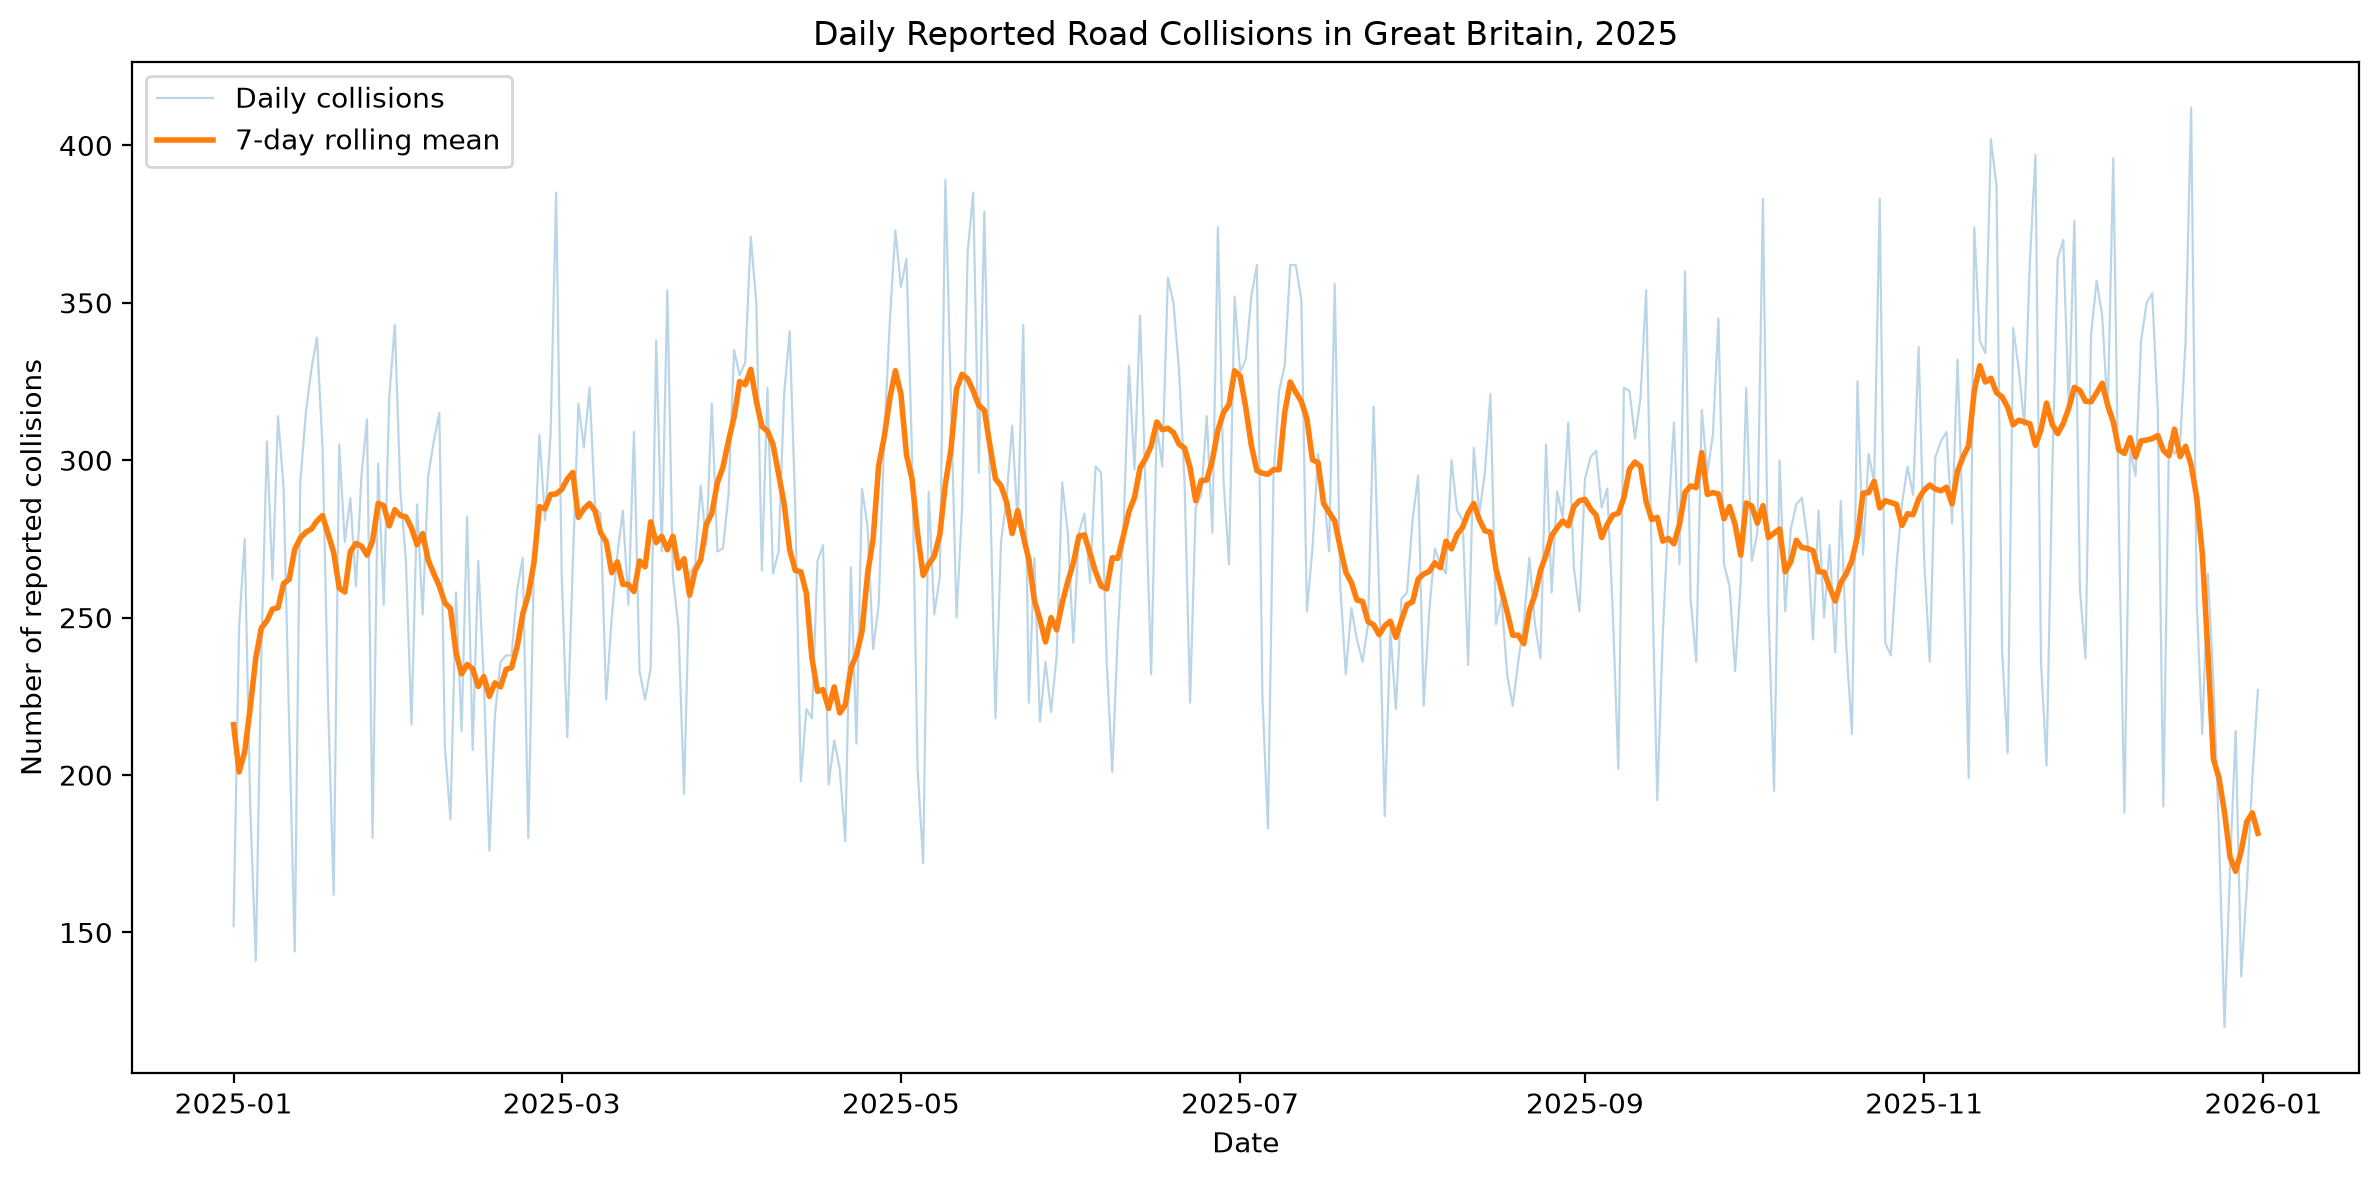

In [405]:
# Plot daily collision counts and the seven-day rolling mean

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    rq1_daily.index,
    rq1_daily["daily_collisions"],
    alpha=0.3,
    linewidth=0.8,
    label="Daily collisions"
)

ax.plot(
    rq1_daily.index,
    rq1_daily["rolling_7_day"],
    linewidth=2,
    label="7-day rolling mean"
)

ax.set_title(
    "Daily Reported Road Collisions in Great Britain, 2025"
)
ax.set_xlabel("Date")
ax.set_ylabel("Number of reported collisions")

ax.legend()

plt.tight_layout()

save_and_show(fig, FIG_DIR / "daily_collisions_rolling_mean.png")

In [406]:
# Summarise daily and seven-day extremes

highest_day = rq1_daily["daily_collisions"].idxmax()
lowest_day = rq1_daily["daily_collisions"].idxmin()

highest_rolling_date = rq1_daily["rolling_7_day"].idxmax()
lowest_rolling_date = rq1_daily["rolling_7_day"].idxmin()

rq1_extremes = pd.DataFrame({
    "Period": [
        highest_day.date(),
        lowest_day.date(),
        (
            f"{(highest_rolling_date - pd.Timedelta(days=3)).date()} "
            f"to {(highest_rolling_date + pd.Timedelta(days=3)).date()}"
        ),
        (
            f"{(lowest_rolling_date - pd.Timedelta(days=3)).date()} "
            f"to {(lowest_rolling_date + pd.Timedelta(days=3)).date()}"
        )
    ],
    "Value": [
        rq1_daily.loc[highest_day, "daily_collisions"],
        rq1_daily.loc[lowest_day, "daily_collisions"],
        rq1_daily.loc[highest_rolling_date, "rolling_7_day"],
        rq1_daily.loc[lowest_rolling_date, "rolling_7_day"]
    ]
}, index=[
    "Highest daily count",
    "Lowest daily count",
    "Highest 7-day mean",
    "Lowest 7-day mean"
])

display(rq1_extremes.round(2))

,Period,Value
Highest daily count,2025-12-19,412.00
Lowest daily count,2025-12-25,120.00
Highest 7-day mean,2025-11-08 to 2025-11-14,330.00
Lowest 7-day mean,2025-12-24 to 2025-12-30,169.43


In [407]:
#  Compare the months with the highest and lowest mean daily collision counts

highest_month = monthly_daily_mean.idxmax()
lowest_month = monthly_daily_mean.idxmin()

monthly_difference = (
    monthly_daily_mean.max()
    - monthly_daily_mean.min()
)

monthly_pct_difference = (
    monthly_difference
    / monthly_daily_mean.min()
    * 100
)

print(
    f"{highest_month} had the highest mean daily count "
    f"({monthly_daily_mean.max():.2f}), compared with "
    f"{monthly_daily_mean.min():.2f} in {lowest_month}; "
    f"a difference of {monthly_difference:.2f} "
    f"({monthly_pct_difference:.1f}%)."
)

November had the highest mean daily count (306.20), compared with 255.54 in February; a difference of 50.66 (19.8%).


### 5.2 RQ2 - Temporal patterns in collision severity

To examine temporal variation in recorded collision severity, the proportion of collisions classified as fatal or serious was calculated within each hour of the day and day of the week. Proportions are used rather than raw fatal-or-serious counts because the total number of reported collisions differs substantially between time periods. A day-of-week by hour heatmap is then used to examine whether higher-severity collisions are concentrated within particular temporal combinations.

In [408]:
# Calculate collision frequency and fatal-or-serious proportion by hour

rq2_hourly = (
    collisions
    .groupby("hour")
    .agg(
        total_collisions=("collision_index", "size"),
        fatal_or_serious=("is_fatal_or_serious", "sum")
    )
)

rq2_hourly["fatal_or_serious_pct"] = (
    rq2_hourly["fatal_or_serious"]
    / rq2_hourly["total_collisions"]
    * 100
)

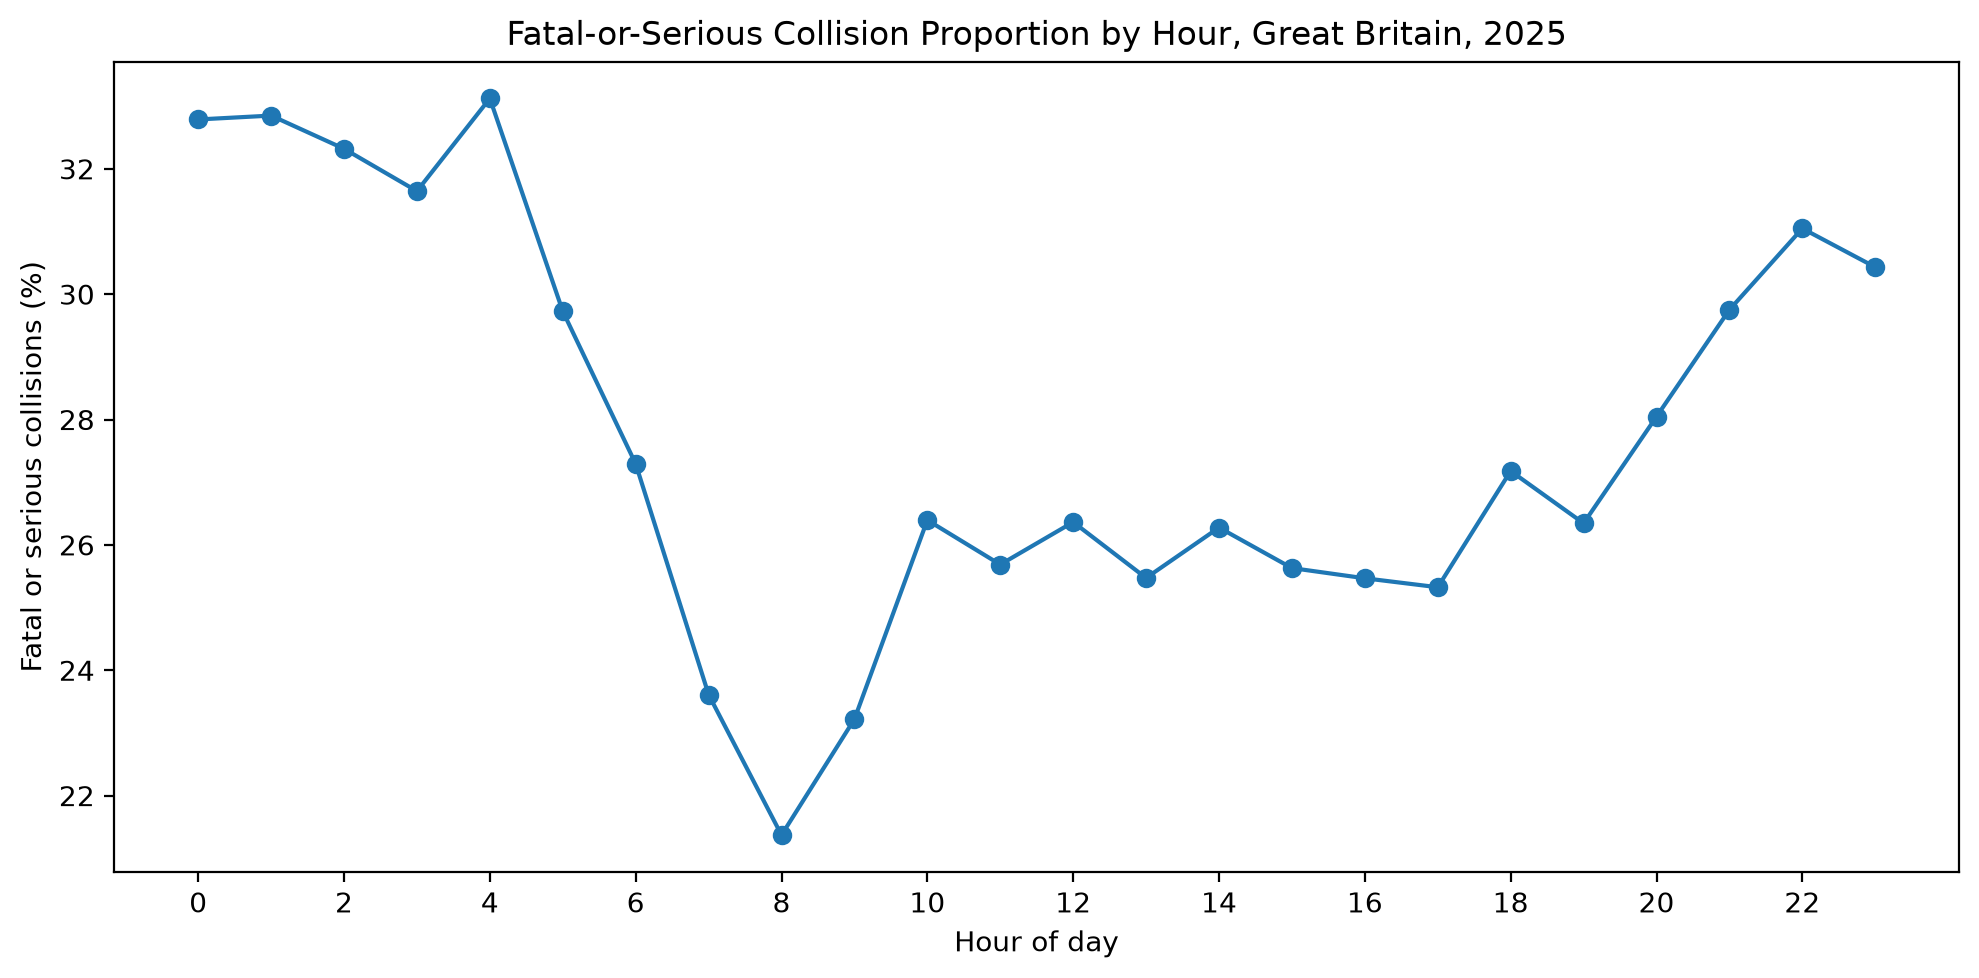

In [409]:
# Plot the proportion of fatal-or-serious collisions by hour

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    rq2_hourly.index,
    rq2_hourly["fatal_or_serious_pct"],
    marker="o"
)

ax.set_title(
    "Fatal-or-Serious Collision Proportion by Hour, Great Britain, 2025"
)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fatal or serious collisions (%)")

ax.set_xticks(range(0, 24, 2))

plt.tight_layout()

save_and_show(fig, FIG_DIR / "fatal_serious_by_hour.png")

In [410]:
# Calculate collision frequency and fatal-or-serious proportion by weekday

rq2_weekday = (
    collisions
    .groupby("day_of_week", observed=False)
    .agg(
        total_collisions=("collision_index", "size"),
        fatal_or_serious=("is_fatal_or_serious", "sum")
    )
)

rq2_weekday["fatal_or_serious_pct"] = (
    rq2_weekday["fatal_or_serious"]
    / rq2_weekday["total_collisions"]
    * 100
)

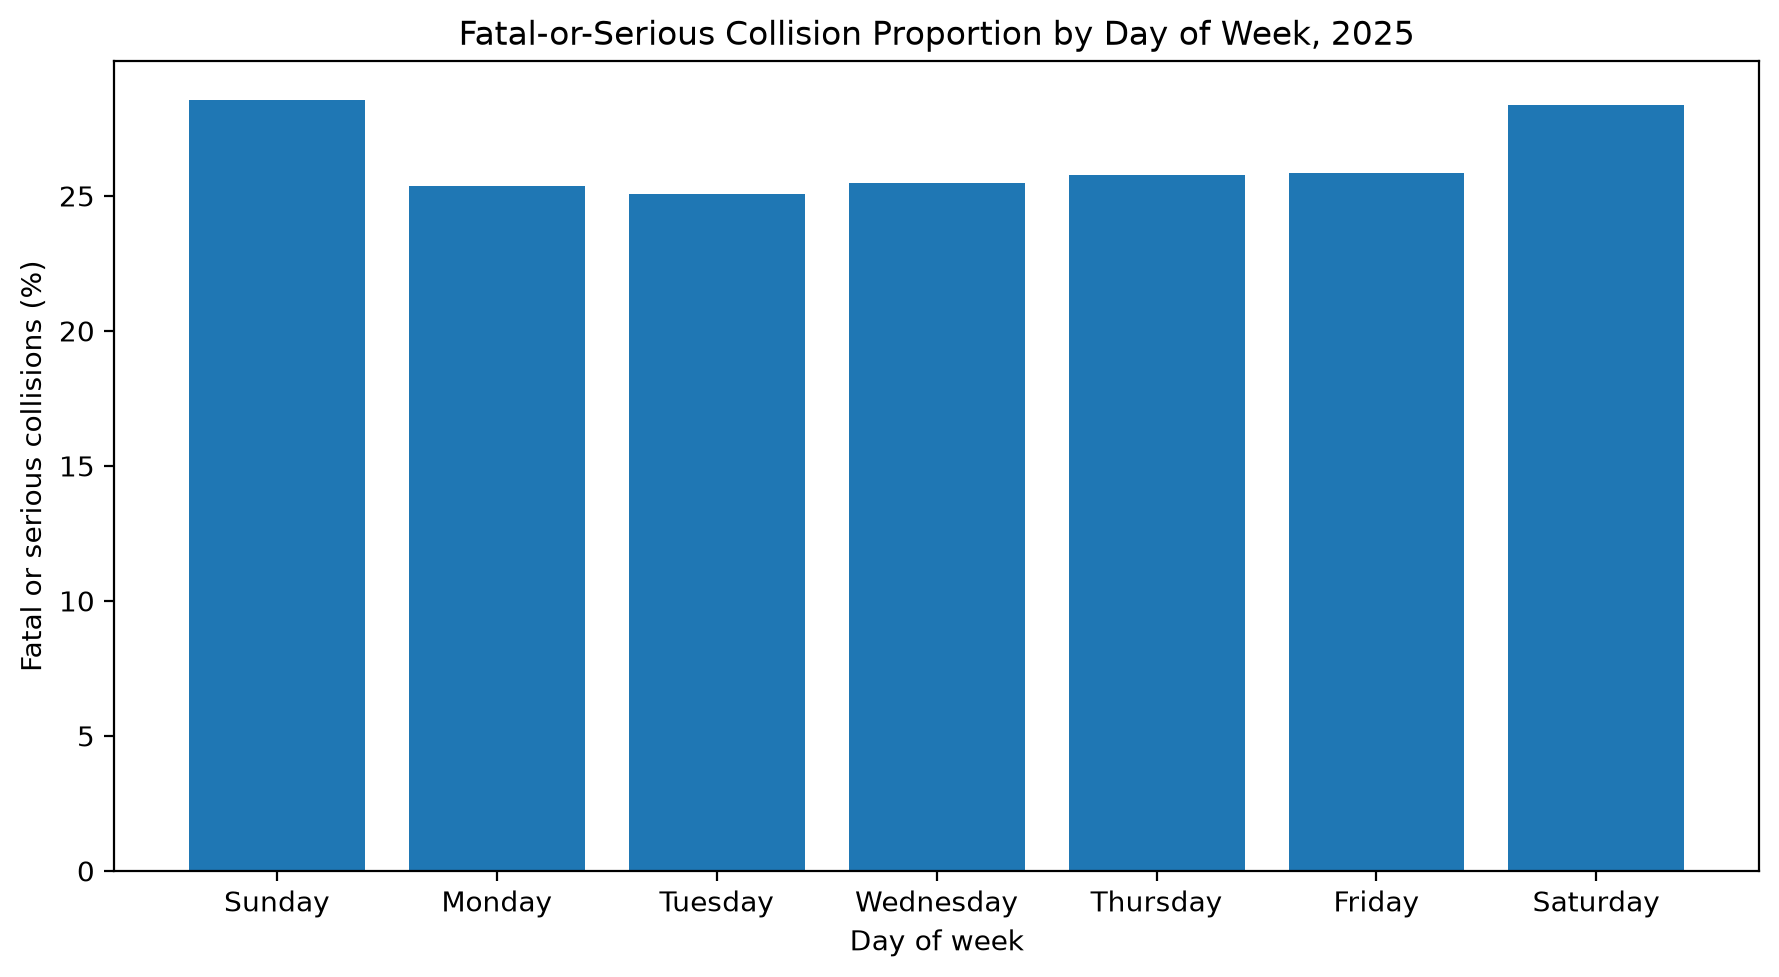

In [411]:
# Plot the proportion of fatal-or-serious collisions by weekday

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    rq2_weekday.index.astype(str),
    rq2_weekday["fatal_or_serious_pct"]
)

ax.set_title(
    "Fatal-or-Serious Collision Proportion by Day of Week, 2025"
)
ax.set_xlabel("Day of week")
ax.set_ylabel("Fatal or serious collisions (%)")

plt.tight_layout()

save_and_show(fig, FIG_DIR / "fatal_serious_by_weekday.png")

In [412]:
# Calculate the fatal-or-serious proportion for each weekday-hour combination

rq2_heatmap = (
    collisions
    .groupby(
        ["day_of_week", "hour"],
        observed=False
    )["is_fatal_or_serious"]
    .mean()
    .mul(100)
    .unstack("hour")
)

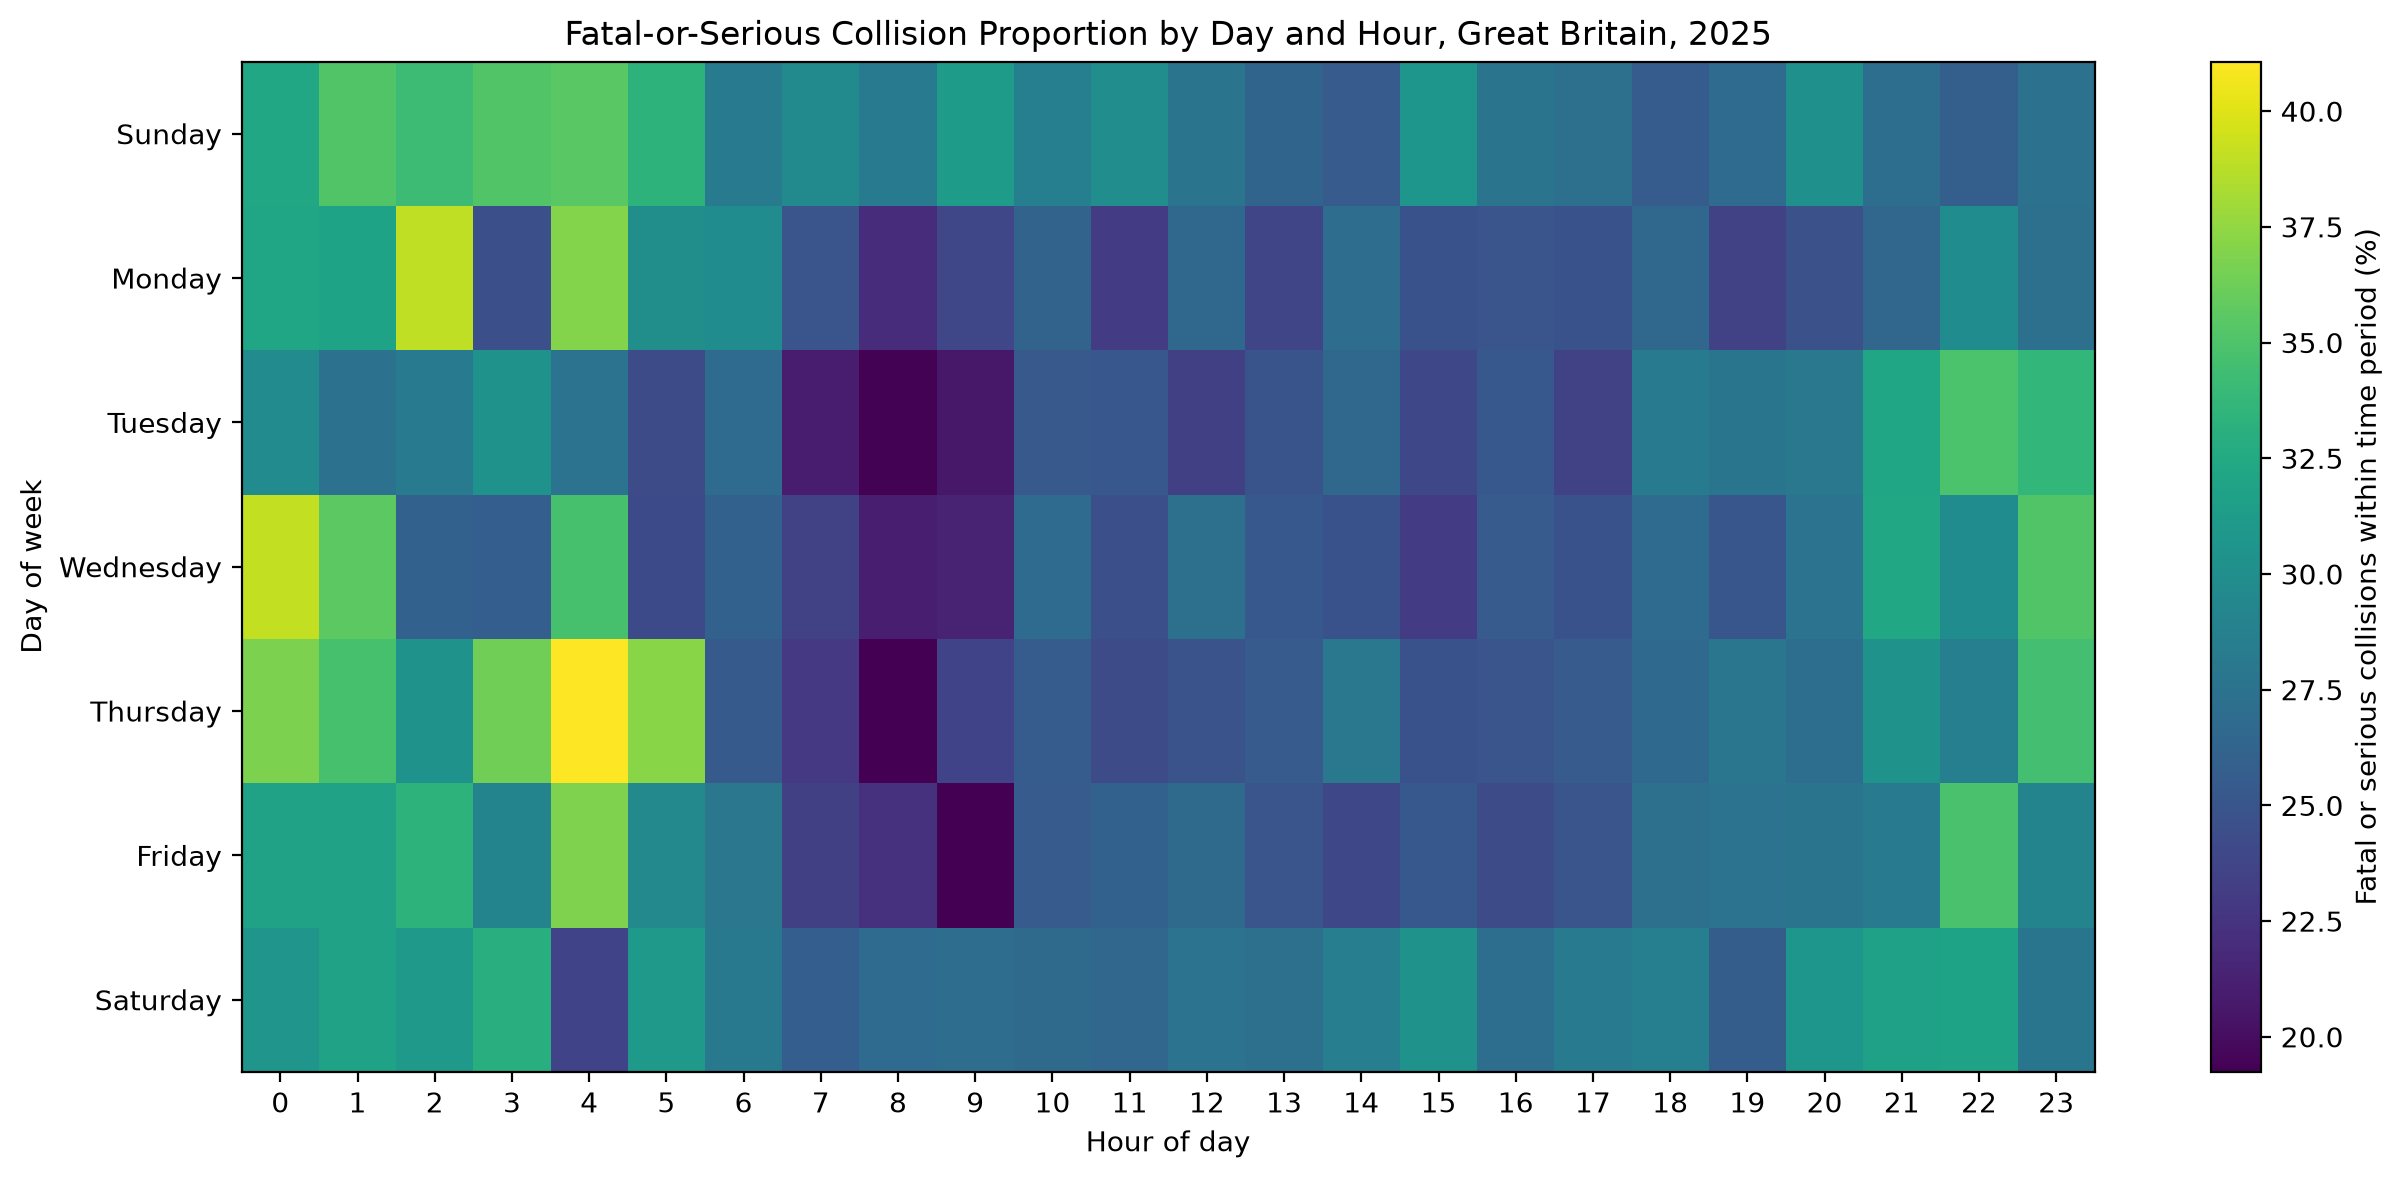

In [413]:
# Visualise the variation in fatal-or-serious collision proportions across weekday-hour combinations

fig, ax = plt.subplots(figsize=(13, 6))

image = ax.imshow(
    rq2_heatmap.values,
    aspect="auto"
)

ax.set_title(
    "Fatal-or-Serious Collision Proportion by Day and Hour, Great Britain, 2025"
)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")

ax.set_xticks(range(24))
ax.set_xticklabels(range(24))

ax.set_yticks(range(len(rq2_heatmap.index)))
ax.set_yticklabels(
    rq2_heatmap.index.astype(str)
)

colourbar = fig.colorbar(
    image,
    ax=ax
)

colourbar.set_label(
    "Fatal or serious collisions within time period (%)"
)

plt.tight_layout()

save_and_show(fig, FIG_DIR / "fatal_serious_heatmap.png")

In [414]:
# Count observations within each weekday-hour combination

rq2_cell_counts = (
    collisions
    .groupby(
        ["day_of_week", "hour"],
        observed=False
    )
    .size()
    .unstack("hour")
)

print(
    f"Smallest weekday-hour cell: "
    f"{rq2_cell_counts.min().min():,} collisions"
)

print(
    f"Largest weekday-hour cell: "
    f"{rq2_cell_counts.max().max():,} collisions"
)

Smallest weekday-hour cell: 55 collisions
Largest weekday-hour cell: 1,530 collisions


In [415]:
# Summarise the highest and lowest severity proportions

highest_hour = rq2_hourly["fatal_or_serious_pct"].idxmax()
lowest_hour = rq2_hourly["fatal_or_serious_pct"].idxmin()

highest_weekday = rq2_weekday["fatal_or_serious_pct"].idxmax()
lowest_weekday = rq2_weekday["fatal_or_serious_pct"].idxmin()

stacked_heatmap = rq2_heatmap.stack()

highest_cell = stacked_heatmap.idxmax()
lowest_cell = stacked_heatmap.idxmin()

rq2_extremes = pd.DataFrame({
    "Highest": [
        f"{highest_hour:02d}:00",
        str(highest_weekday),
        f"{highest_cell[0]}, {highest_cell[1]:02d}:00"
    ],
    "Highest percentage": [
        rq2_hourly.loc[highest_hour, "fatal_or_serious_pct"],
        rq2_weekday.loc[highest_weekday, "fatal_or_serious_pct"],
        stacked_heatmap.max()
    ],
    "Lowest": [
        f"{lowest_hour:02d}:00",
        str(lowest_weekday),
        f"{lowest_cell[0]}, {lowest_cell[1]:02d}:00"
    ],
    "Lowest percentage": [
        rq2_hourly.loc[lowest_hour, "fatal_or_serious_pct"],
        rq2_weekday.loc[lowest_weekday, "fatal_or_serious_pct"],
        stacked_heatmap.min()
    ]
}, index=[
    "Hour of day",
    "Day of week",
    "Weekday-hour combination"
])

display(rq2_extremes.round(2))

,Highest,Highest percentage,Lowest,Lowest percentage
Hour of day,04:00,33.12,08:00,21.37
Day of week,Sunday,28.55,Tuesday,25.08
Weekday-hour combination,"Thursday, 04:00",41.07,"Thursday, 08:00",19.24


### 5.3 RQ3 - Spatial distribution and severity

Spatial severity was examined using two hexagonal aggregations: one showing the concentration of fatal-or-serious collisions and a second showing the fatal-or-serious proportion within each spatial cell. A minimum cell count was applied to the proportional map to reduce instability in sparsely populated areas.

In [416]:
# Select collisions recorded as fatal or serious

rq3_severe = collisions.loc[
    collisions["is_fatal_or_serious"]
].copy()

severe_count = len(rq3_severe)
severe_pct = severe_count / len(collisions) * 100

print(f"All collisions: {len(collisions):,}")
print(f"Fatal or serious collisions: {severe_count:,}")
print(f"Fatal or serious proportion: {severe_pct:.2f}%")

All collisions: 101,523
Fatal or serious collisions: 26,643
Fatal or serious proportion: 26.24%


In [417]:
# Define a consistent extent for spatial comparisons

rq3_extent = [
    collisions["longitude"].min(),
    collisions["longitude"].max(),
    collisions["latitude"].min(),
    collisions["latitude"].max()
]

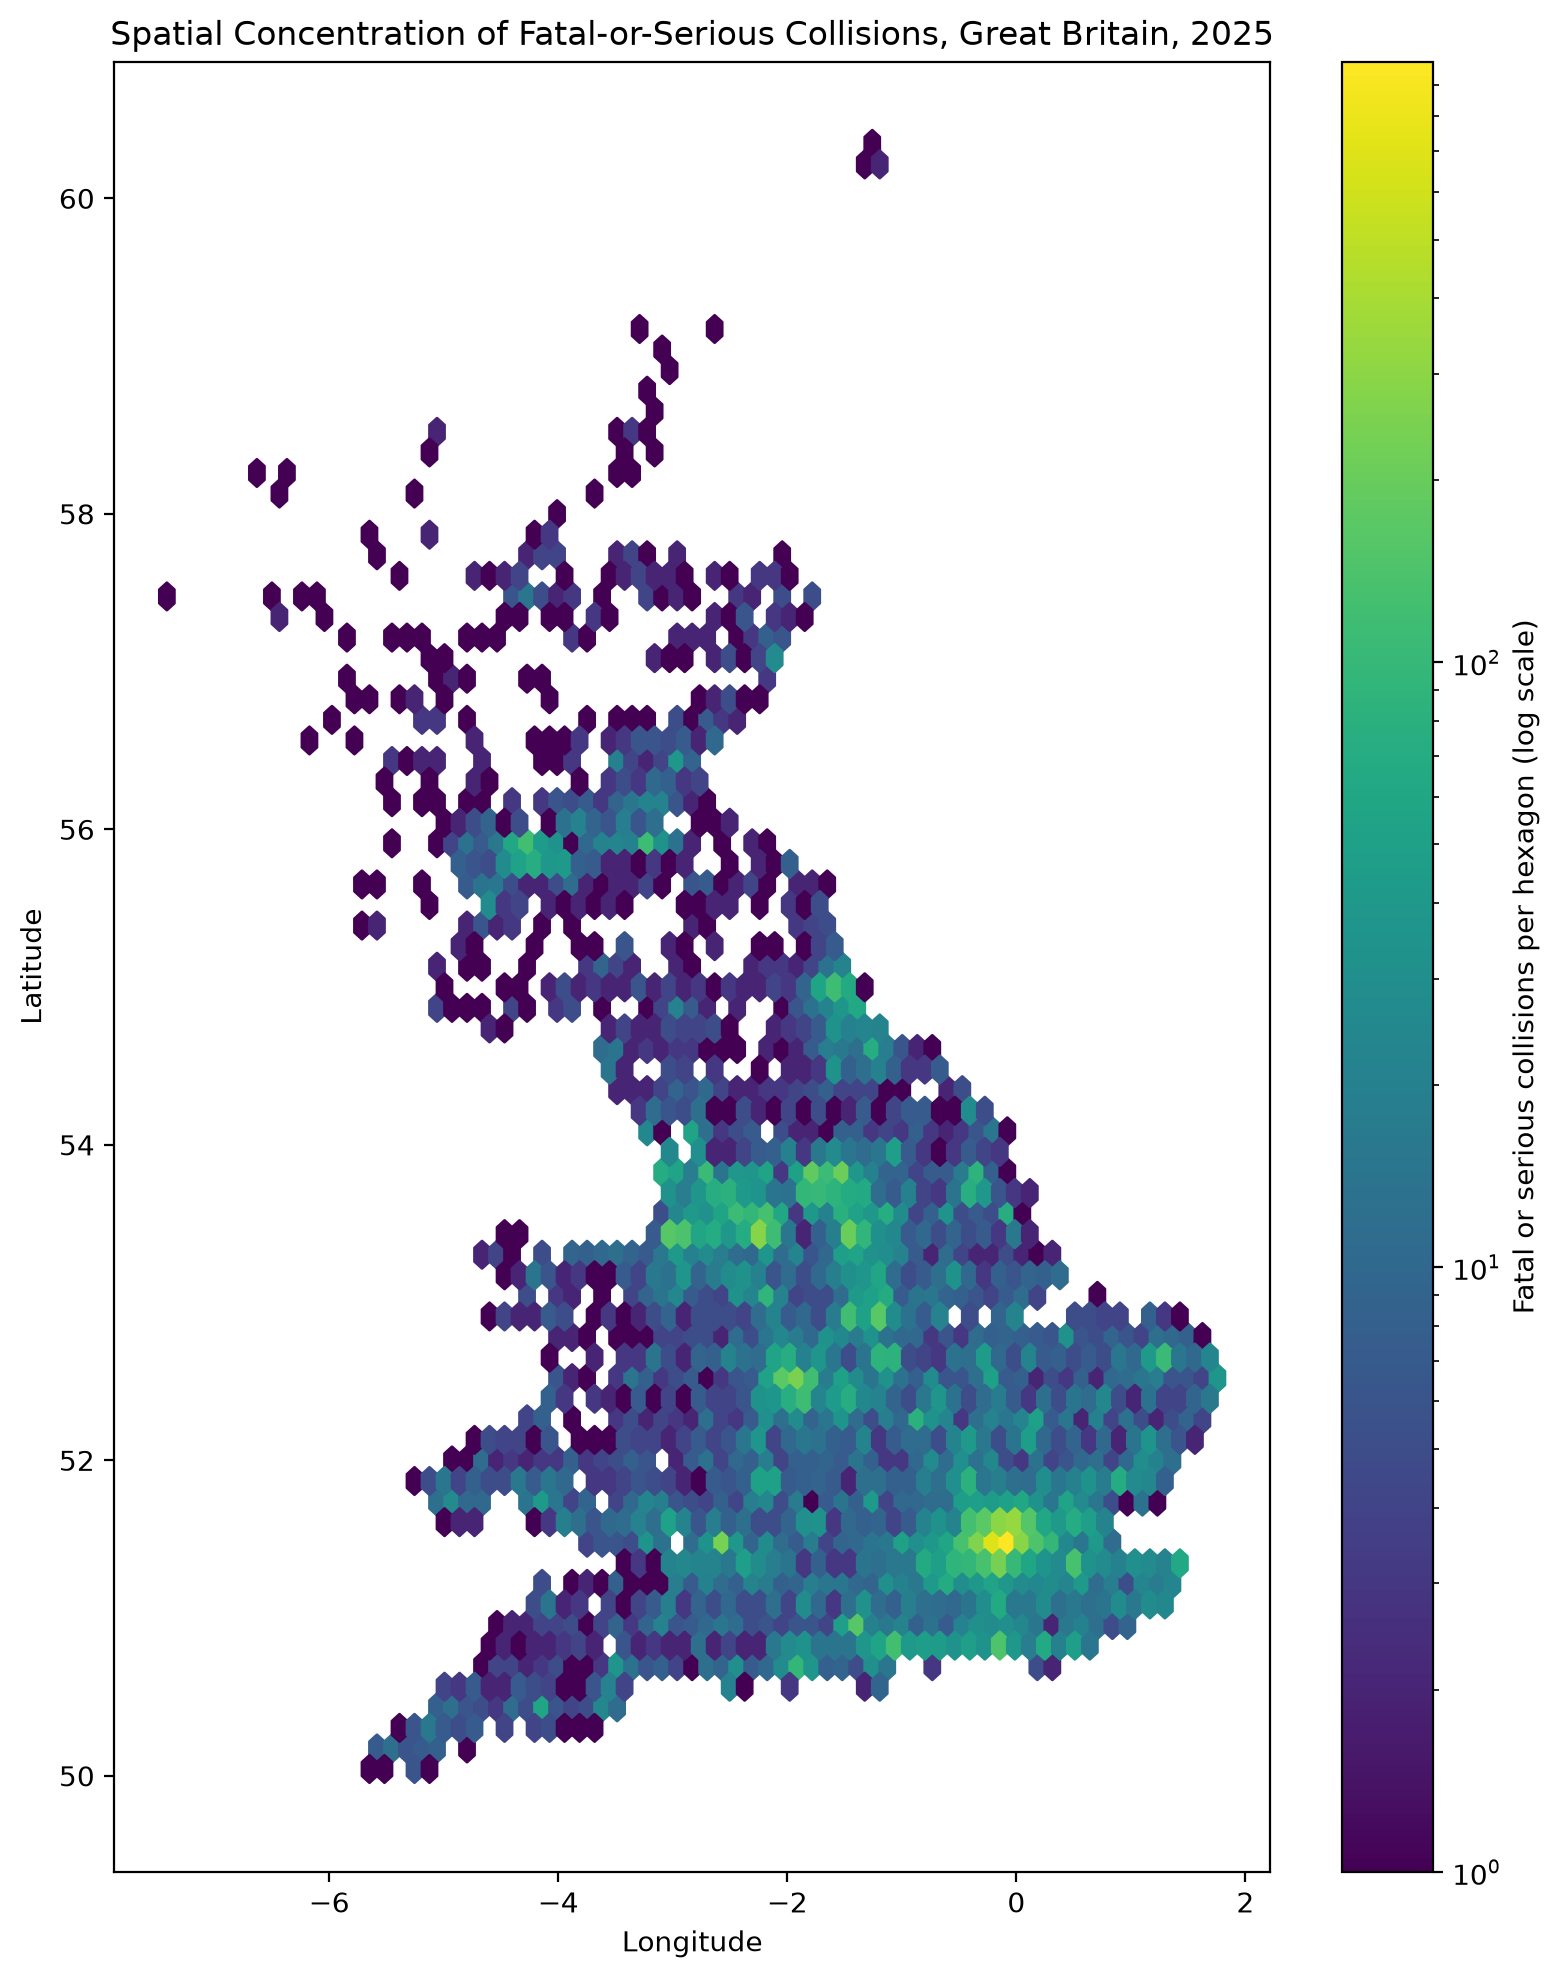

In [418]:
# Visualise the spatial concentration of fatal-or-serious collisions using hexagonal binning

fig, ax = plt.subplots(figsize=(8, 10))

severe_hex = ax.hexbin(
    rq3_severe["longitude"],
    rq3_severe["latitude"],
    gridsize=70,
    extent=rq3_extent,
    mincnt=1,
    bins="log"
)

ax.set_title(
    "Spatial Concentration of Fatal-or-Serious Collisions, "
    "Great Britain, 2025"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

colourbar = fig.colorbar(
    severe_hex,
    ax=ax
)

colourbar.set_label(
    "Fatal or serious collisions per hexagon (log scale)"
)

plt.tight_layout()

save_and_show(fig, FIG_DIR / "fatal_serious_spatial_concentration.png")

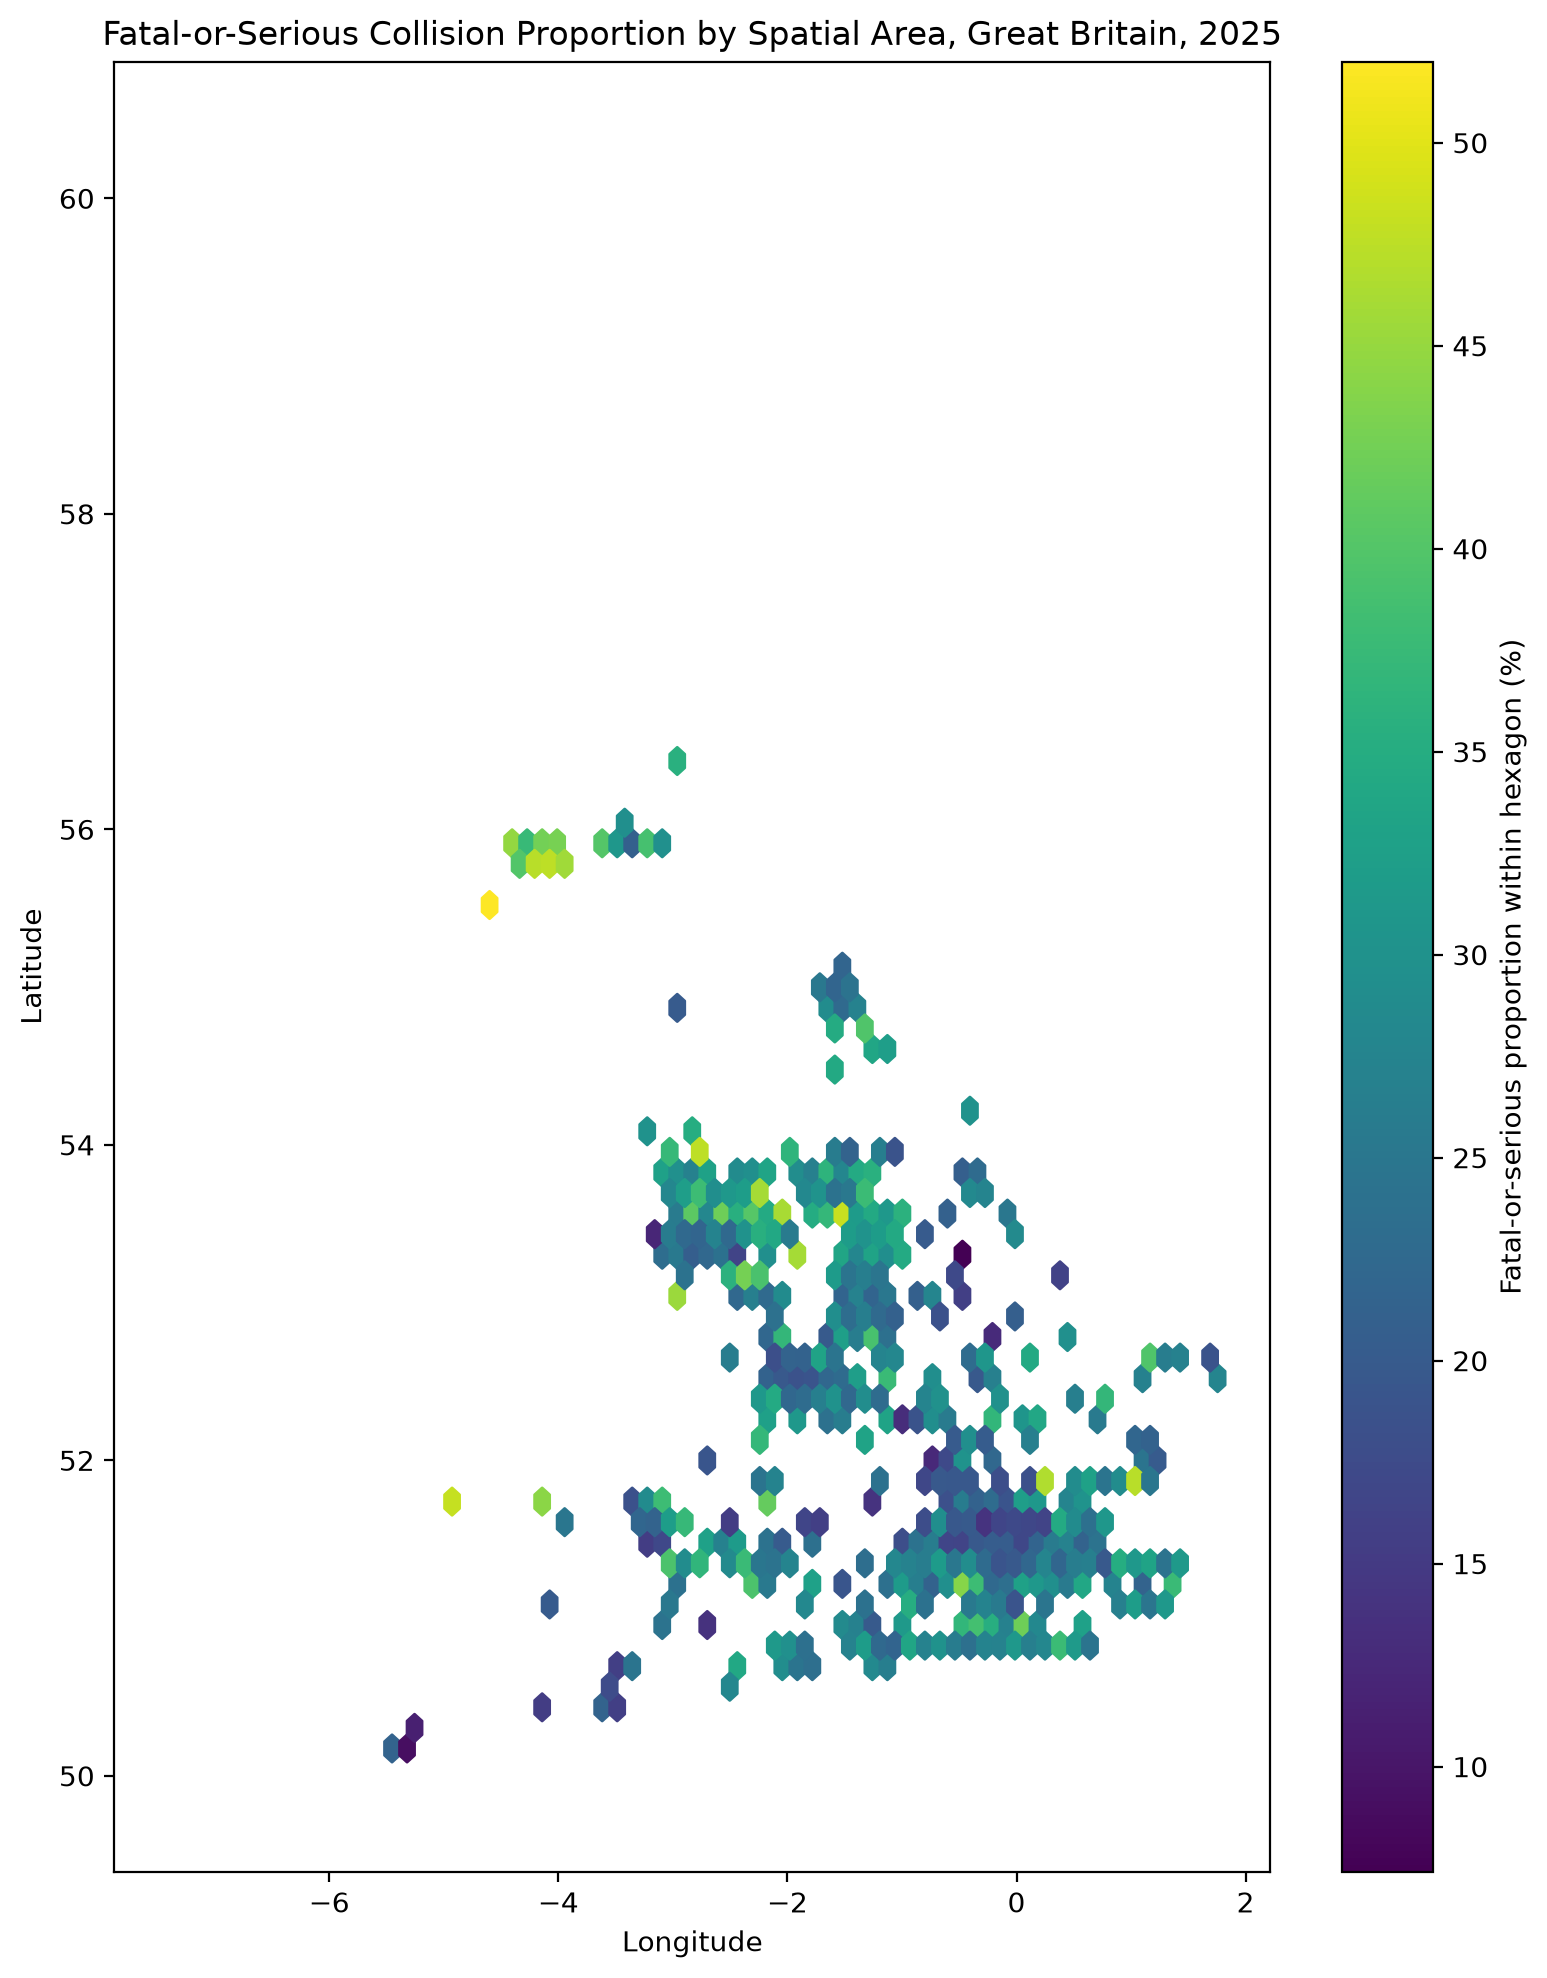

In [419]:
# Map the local fatal-or-serious collision proportion across sufficiently populated spatial cells

fig, ax = plt.subplots(figsize=(8, 10))

severity_proportion_hex = ax.hexbin(
    collisions["longitude"],
    collisions["latitude"],
    C=collisions["is_fatal_or_serious"].astype(float) * 100,
    reduce_C_function=np.mean,
    gridsize=70,
    extent=rq3_extent,
    mincnt=50
)

ax.set_title(
    "Fatal-or-Serious Collision Proportion by Spatial Area, "
    "Great Britain, 2025"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

colourbar = fig.colorbar(
    severity_proportion_hex,
    ax=ax
)

colourbar.set_label(
    "Fatal-or-serious proportion within hexagon (%)"
)

plt.tight_layout()

save_and_show(fig, FIG_DIR / "fatal_serious_spatial_proportion.png")

In [420]:
# Summarise the displayed spatial severity distribution

displayed_cells = len(
    severity_proportion_hex.get_array()
)

spatial_severity_values = np.ma.asarray(
    severity_proportion_hex.get_array()
)

cell_centres = severity_proportion_hex.get_offsets()

severity_values = np.ma.filled(
    spatial_severity_values,
    np.nan
)

highest_cell_index = np.nanargmax(severity_values)
lowest_cell_index = np.nanargmin(severity_values)

spatial_summary = pd.DataFrame({
    "Statistic": [
        "Displayed hexagons",
        "Lowest fatal-or-serious proportion",
        "Median fatal-or-serious proportion",
        "Highest fatal-or-serious proportion"
    ],
    "Value": [
        displayed_cells,
        np.ma.min(spatial_severity_values),
        np.ma.median(spatial_severity_values),
        np.ma.max(spatial_severity_values)
    ]
})

display(spatial_summary.round(2))

spatial_extremes = pd.DataFrame({
    "Longitude": [
        cell_centres[highest_cell_index, 0],
        cell_centres[lowest_cell_index, 0]
    ],
    "Latitude": [
        cell_centres[highest_cell_index, 1],
        cell_centres[lowest_cell_index, 1]
    ],
    "Fatal or serious (%)": [
        severity_values[highest_cell_index],
        severity_values[lowest_cell_index]
    ]
}, index=[
    "Highest displayed proportion",
    "Lowest displayed proportion"
])

display(spatial_extremes.round(2))

,Statistic,Value
0,Displayed hexagons,414.00
1,Lowest fatal-or-serious proportion,7.41
2,Median fatal-or-serious proportion,26.80
3,Highest fatal-or-serious proportion,52.00


,Longitude,Latitude,Fatal or serious (%)
Highest displayed proportion,-4.60,55.52,52.00
Lowest displayed proportion,-0.47,53.30,7.41


### 5.4 RQ4 - Road environment and collision outcomes

Road-environment variables were compared using both collision frequency and within-category fatal-or-serious proportions. Unknown or unresolved categories were excluded where appropriate to support interpretable comparisons.

In [421]:
# Define a reusable function to summarise road-environment collision frequency and severity

def summarise_road_environment(data, variable):
    """
    Summarise collision frequency and fatal-or-serious severity
    for a categorical road-environment variable.
    """
    summary = (
        data
        .groupby(variable, observed=False)
        .agg(
            total_collisions=("collision_index", "size"),
            fatal_or_serious=("is_fatal_or_serious", "sum")
        )
    )

    summary["collision_share_pct"] = (
        summary["total_collisions"]
        / summary["total_collisions"].sum()
        * 100
    )

    summary["fatal_or_serious_pct"] = (
        summary["fatal_or_serious"]
        / summary["total_collisions"]
        * 100
    )

    return summary

#### 5.4.1 Road Type

In [422]:
# Summarise the road type variable, excluding unknown or missing categories

rq4_road_data = collisions.loc[
    ~collisions["road_type"].isin([
        "Unknown",
        "Data missing or out of range"
    ])
].copy()

rq4_road = summarise_road_environment(
    rq4_road_data,
    "road_type"
)

rq4_road = rq4_road.sort_values(
    "fatal_or_serious_pct"
)

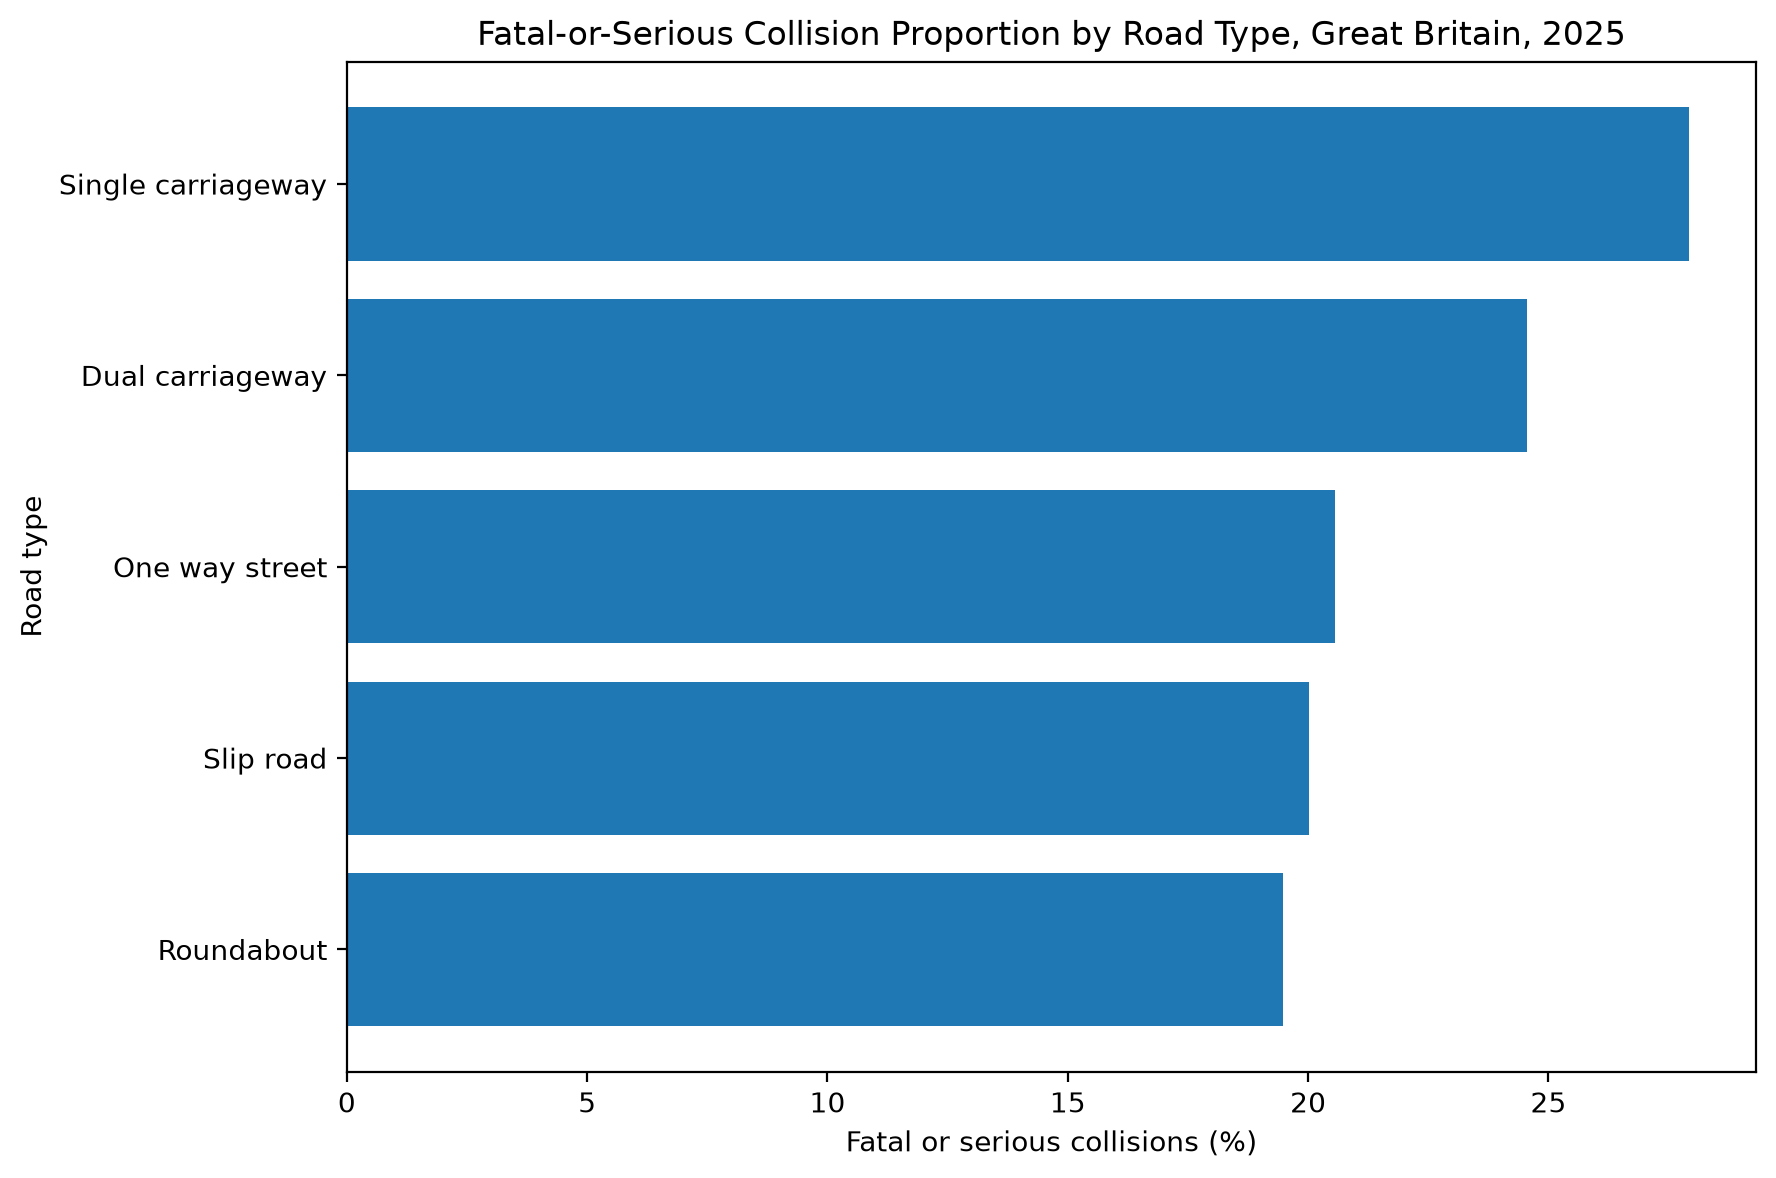

In [423]:
# Visualise the fatal-or-serious collision proportion by road type

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    rq4_road.index.astype(str),
    rq4_road["fatal_or_serious_pct"]
)

ax.set_title(
    "Fatal-or-Serious Collision Proportion by Road Type, "
    "Great Britain, 2025"
)
ax.set_xlabel("Fatal or serious collisions (%)")
ax.set_ylabel("Road type")

plt.tight_layout()

save_and_show(fig, FIG_DIR / "fatal_serious_by_road_type.png")

#### 5.4.2 Speed Limit 

In [424]:
# Summarise collision frequency and severity by recorded speed limit

rq4_speed = summarise_road_environment(
    collisions,
    "speed_limit"
).sort_index()

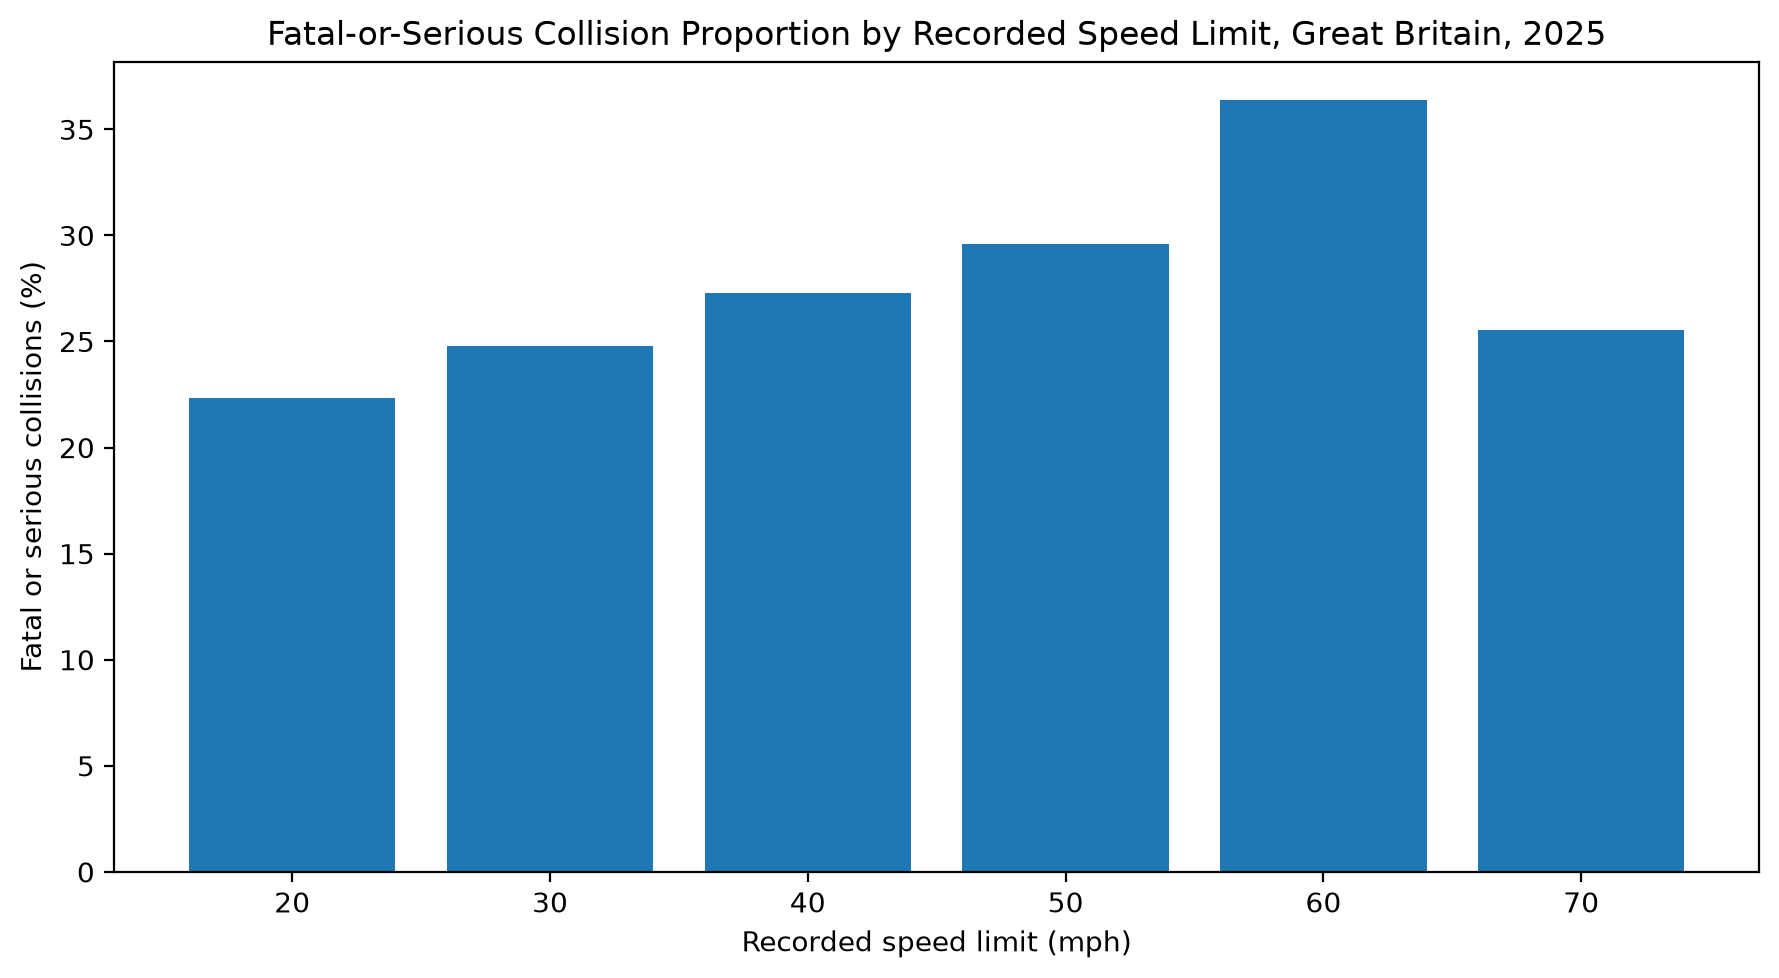

In [425]:
# Visualise the fatal-or-serious collision proportion by recorded speed limit 

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    rq4_speed.index.astype(str),
    rq4_speed["fatal_or_serious_pct"]
)

ax.set_title(
    "Fatal-or-Serious Collision Proportion by Recorded Speed Limit, "
    "Great Britain, 2025"
)
ax.set_xlabel("Recorded speed limit (mph)")
ax.set_ylabel("Fatal or serious collisions (%)")

plt.tight_layout()

save_and_show(fig, FIG_DIR / "fatal_serious_by_speed_limit.png")

#### 5.4.3 Urban Versus Rural

In [426]:
# Summarise the urban-or-rural area variable, excluding unallocated or missing categories 

rq4_area_data = collisions.loc[
    ~collisions["urban_or_rural_area"].isin([
        "Unallocated",
        "Data missing or out of range"
    ])
].copy()

rq4_area = summarise_road_environment(
    rq4_area_data,
    "urban_or_rural_area"
)

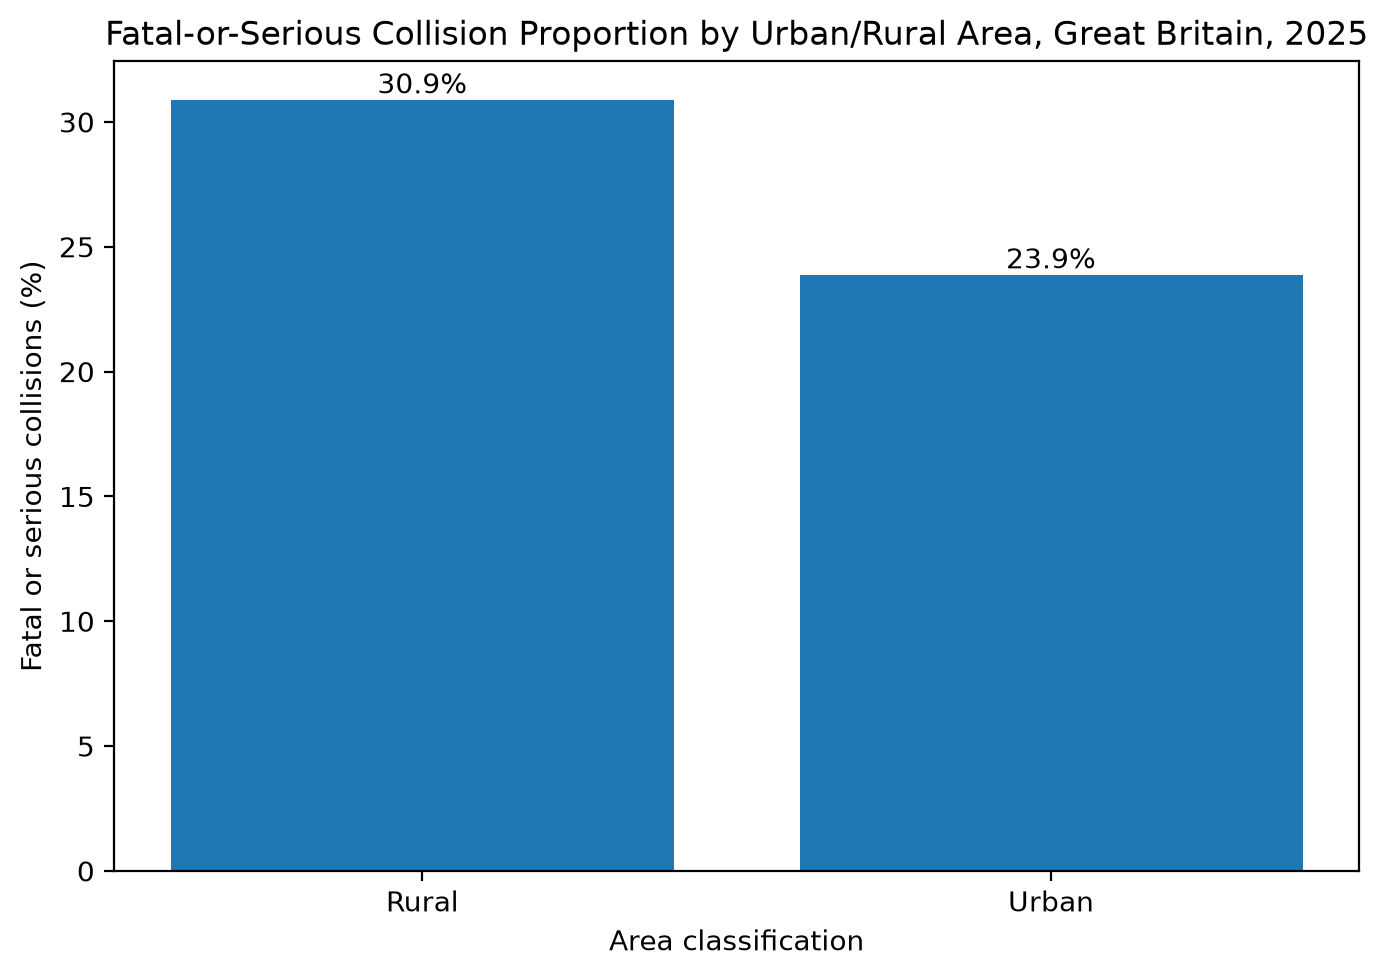

In [427]:
# Visualise the fatal-or-serious collision proportion by urban-or-rural area classification 

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    rq4_area.index.astype(str),
    rq4_area["fatal_or_serious_pct"]
)

ax.set_title(
    "Fatal-or-Serious Collision Proportion by Urban/Rural Area, "
    "Great Britain, 2025"
)
ax.set_xlabel("Area classification")
ax.set_ylabel("Fatal or serious collisions (%)")

for bar, value in zip(
    bars,
    rq4_area["fatal_or_serious_pct"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

save_and_show(fig, FIG_DIR / "fatal_serious_by_urban_rural.png")

In [428]:
# Summarise the main road-environment contrasts

rq4_summary = pd.DataFrame({
    "Most collisions": [
        rq4_road["total_collisions"].idxmax(),
        f"{rq4_speed['total_collisions'].idxmax()} mph",
        rq4_area["total_collisions"].idxmax()
    ],
    "Highest fatal-or-serious category": [
        rq4_road["fatal_or_serious_pct"].idxmax(),
        f"{rq4_speed['fatal_or_serious_pct'].idxmax()} mph",
        rq4_area["fatal_or_serious_pct"].idxmax()
    ],
    "Highest severity (%)": [
        rq4_road["fatal_or_serious_pct"].max(),
        rq4_speed["fatal_or_serious_pct"].max(),
        rq4_area["fatal_or_serious_pct"].max()
    ],
    "Lowest fatal-or-serious category": [
        rq4_road["fatal_or_serious_pct"].idxmin(),
        f"{rq4_speed['fatal_or_serious_pct'].idxmin()} mph",
        rq4_area["fatal_or_serious_pct"].idxmin()
    ],
    "Lowest severity (%)": [
        rq4_road["fatal_or_serious_pct"].min(),
        rq4_speed["fatal_or_serious_pct"].min(),
        rq4_area["fatal_or_serious_pct"].min()
    ]
}, index=[
    "Road type",
    "Speed limit",
    "Urban/rural area"
])

display(rq4_summary.round(2))

print(
    "Road-type records excluded:",
    f"{len(collisions) - len(rq4_road_data):,}"
)

print(
    "Urban/rural records excluded:",
    f"{len(collisions) - len(rq4_area_data):,}"
)

,Most collisions,Highest fatal-or-serious category,Highest severity (%),Lowest fatal-or-serious category,Lowest severity (%)
Road type,Single carriageway,Single carriageway,27.92,Roundabout,19.47
Speed limit,30 mph,60 mph,36.38,20 mph,22.35
Urban/rural area,Urban,Rural,30.88,Urban,23.87


Road-type records excluded: 1,952
Urban/rural records excluded: 2


### 5.5 RQ5 - Environmental conditions and collision outcomes

Light, weather and road-surface conditions were compared using collision frequency and within-category fatal-or-serious proportions. Unknown or unresolved categories were excluded where appropriate, and category sizes were retained to support interpretation of sparse groups.

In [429]:
# Define a reusable function to summarise environmental-condition collision frequency and severity

def summarise_environment(data, variable):
    """
    Summarise collision frequency and fatal-or-serious severity
    for an environmental-condition variable.
    """
    summary = (
        data
        .groupby(variable, observed=False)
        .agg(
            total_collisions=("collision_index", "size"),
            fatal_or_serious=("is_fatal_or_serious", "sum")
        )
    )

    summary["collision_share_pct"] = (
        summary["total_collisions"]
        / summary["total_collisions"].sum()
        * 100
    )

    summary["fatal_or_serious_pct"] = (
        summary["fatal_or_serious"]
        / summary["total_collisions"]
        * 100
    )

    return summary

#### 5.5.1 Light Conditions 

In [430]:
# Summarise the light conditions variable, excluding missing or out-of-range categories 

rq5_light_data = collisions.loc[
    collisions["light_conditions"]
    != "Data missing or out of range"
].copy()

rq5_light = summarise_environment(
    rq5_light_data,
    "light_conditions"
).sort_values(
    "fatal_or_serious_pct"
)

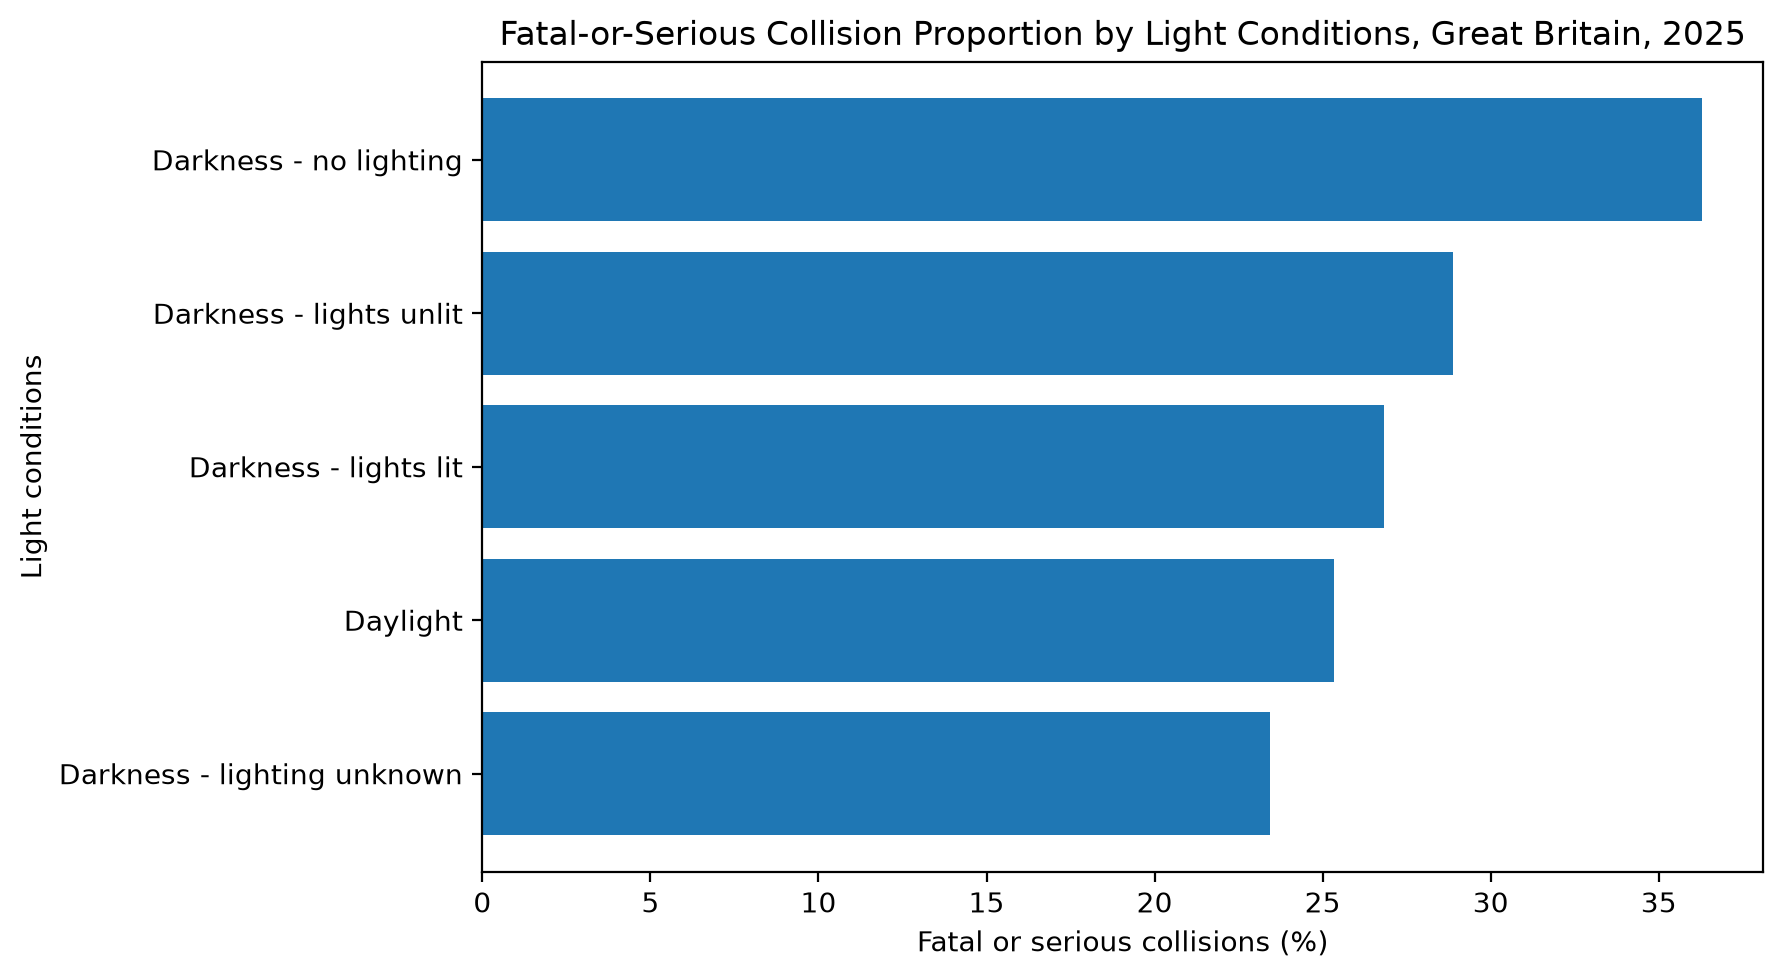

In [431]:
# Visualise the fatal-or-serious collision proportion by light conditions 

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    rq5_light.index.astype(str),
    rq5_light["fatal_or_serious_pct"]
)

ax.set_title(
    "Fatal-or-Serious Collision Proportion by Light Conditions, "
    "Great Britain, 2025"
)
ax.set_xlabel("Fatal or serious collisions (%)")
ax.set_ylabel("Light conditions")

plt.tight_layout()

save_and_show(fig, FIG_DIR / "fatal_serious_by_light_conditions.png")

#### 5.5.2 Weather Conditions 

In [432]:
# Summarise the weather conditions variable, excluding unknown or missing categories 

rq5_weather_data = collisions.loc[
    ~collisions["weather_conditions"].isin([
        "Unknown",
        "Data missing or out of range"
    ])
].copy()

rq5_weather = summarise_environment(
    rq5_weather_data,
    "weather_conditions"
).sort_values(
    "fatal_or_serious_pct"
)

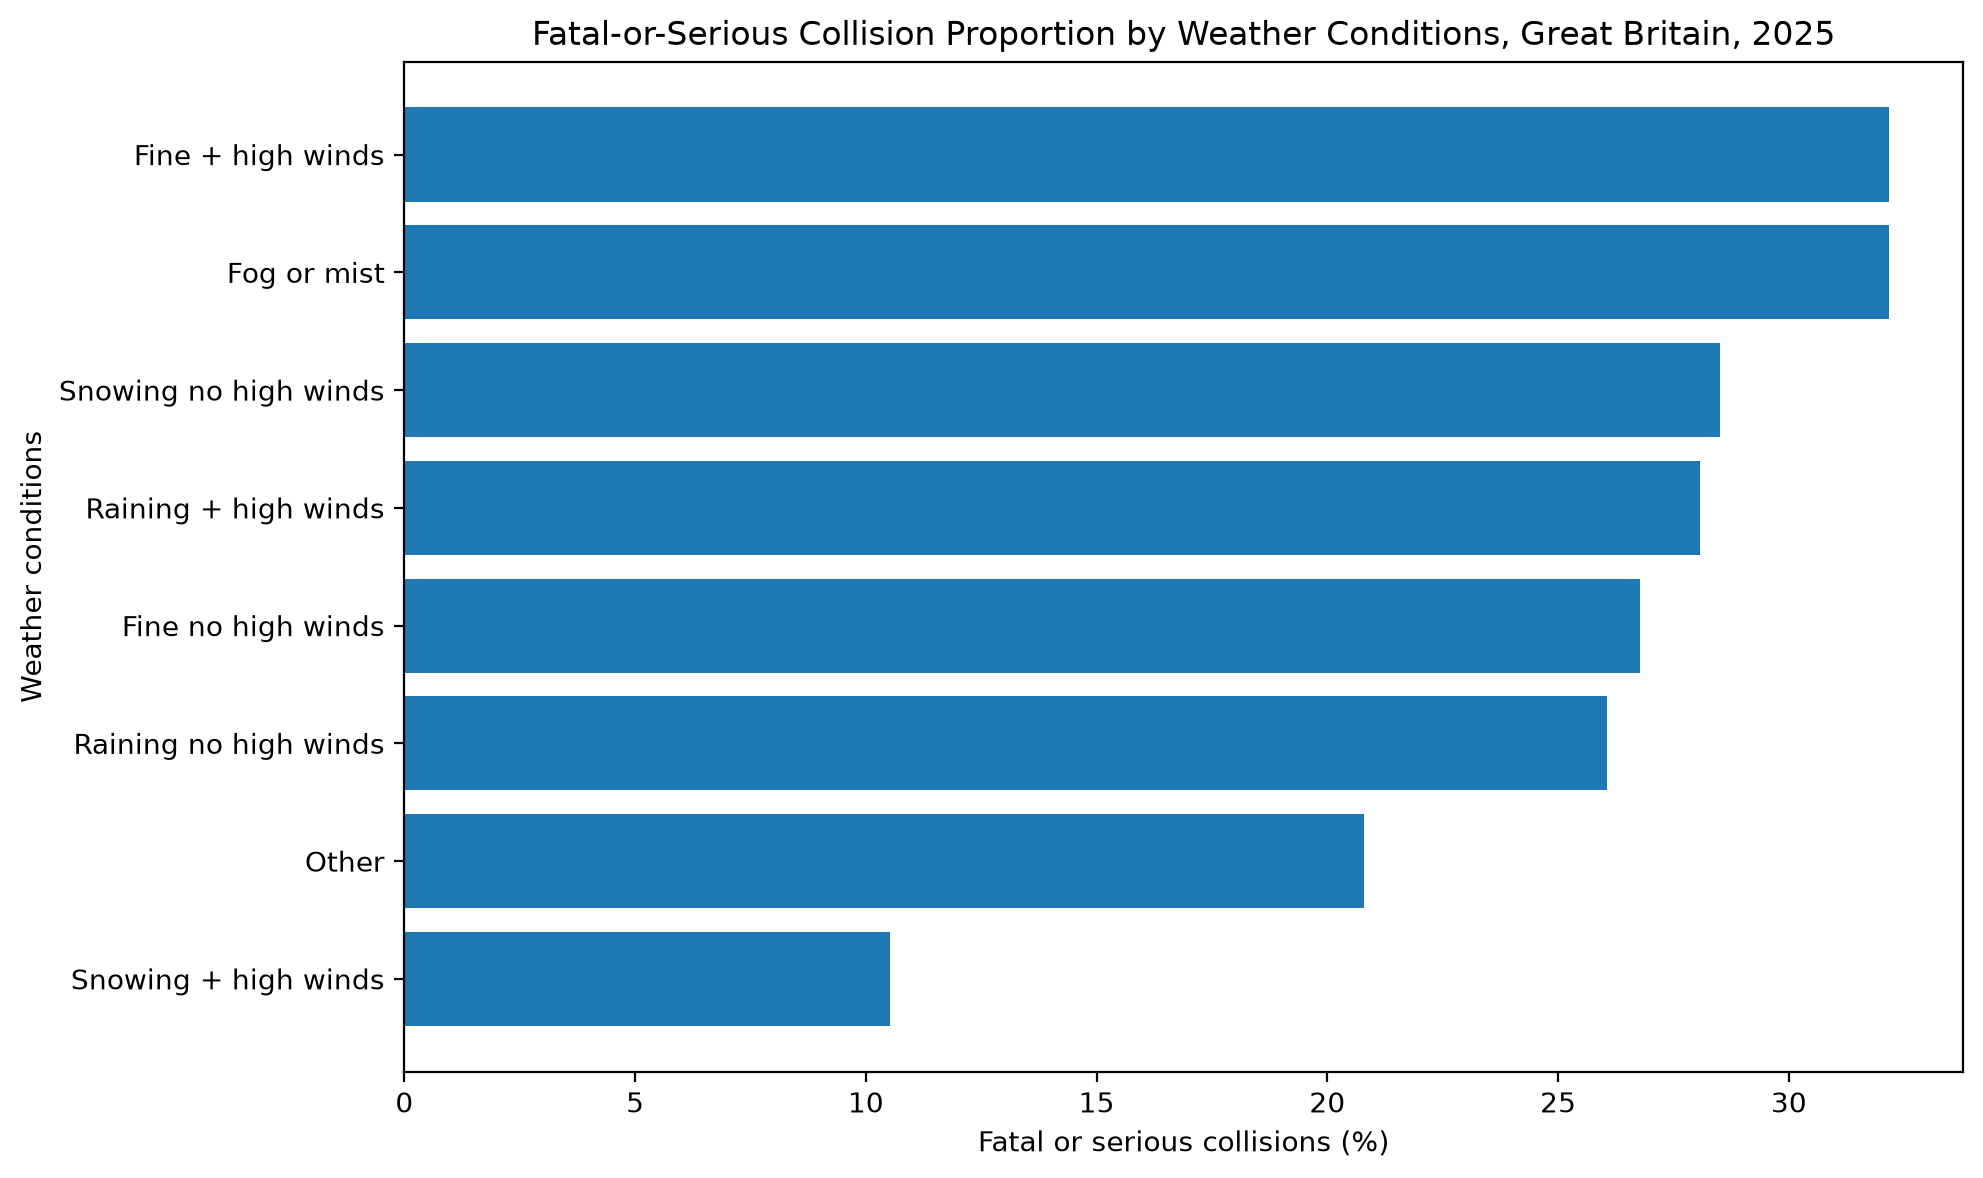

In [433]:
# Visualise the fatal-or-serious collision proportion by weather conditions 

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    rq5_weather.index.astype(str),
    rq5_weather["fatal_or_serious_pct"]
)

ax.set_title(
    "Fatal-or-Serious Collision Proportion by Weather Conditions, "
    "Great Britain, 2025"
)
ax.set_xlabel("Fatal or serious collisions (%)")
ax.set_ylabel("Weather conditions")

plt.tight_layout()

save_and_show(fig, FIG_DIR / "fatal_serious_by_weather_conditions.png")

#### 5.5.3 Road-Surface Conditions 

In [434]:
# Summarise the road-surface conditions variable, excluding unknown or missing categories 

rq5_surface_data = collisions.loc[
    ~collisions["road_surface_conditions"].isin([
        "Unknown",
        "Data missing or out of range"
    ])
].copy()

rq5_surface = summarise_environment(
    rq5_surface_data,
    "road_surface_conditions"
).sort_values(
    "fatal_or_serious_pct"
)

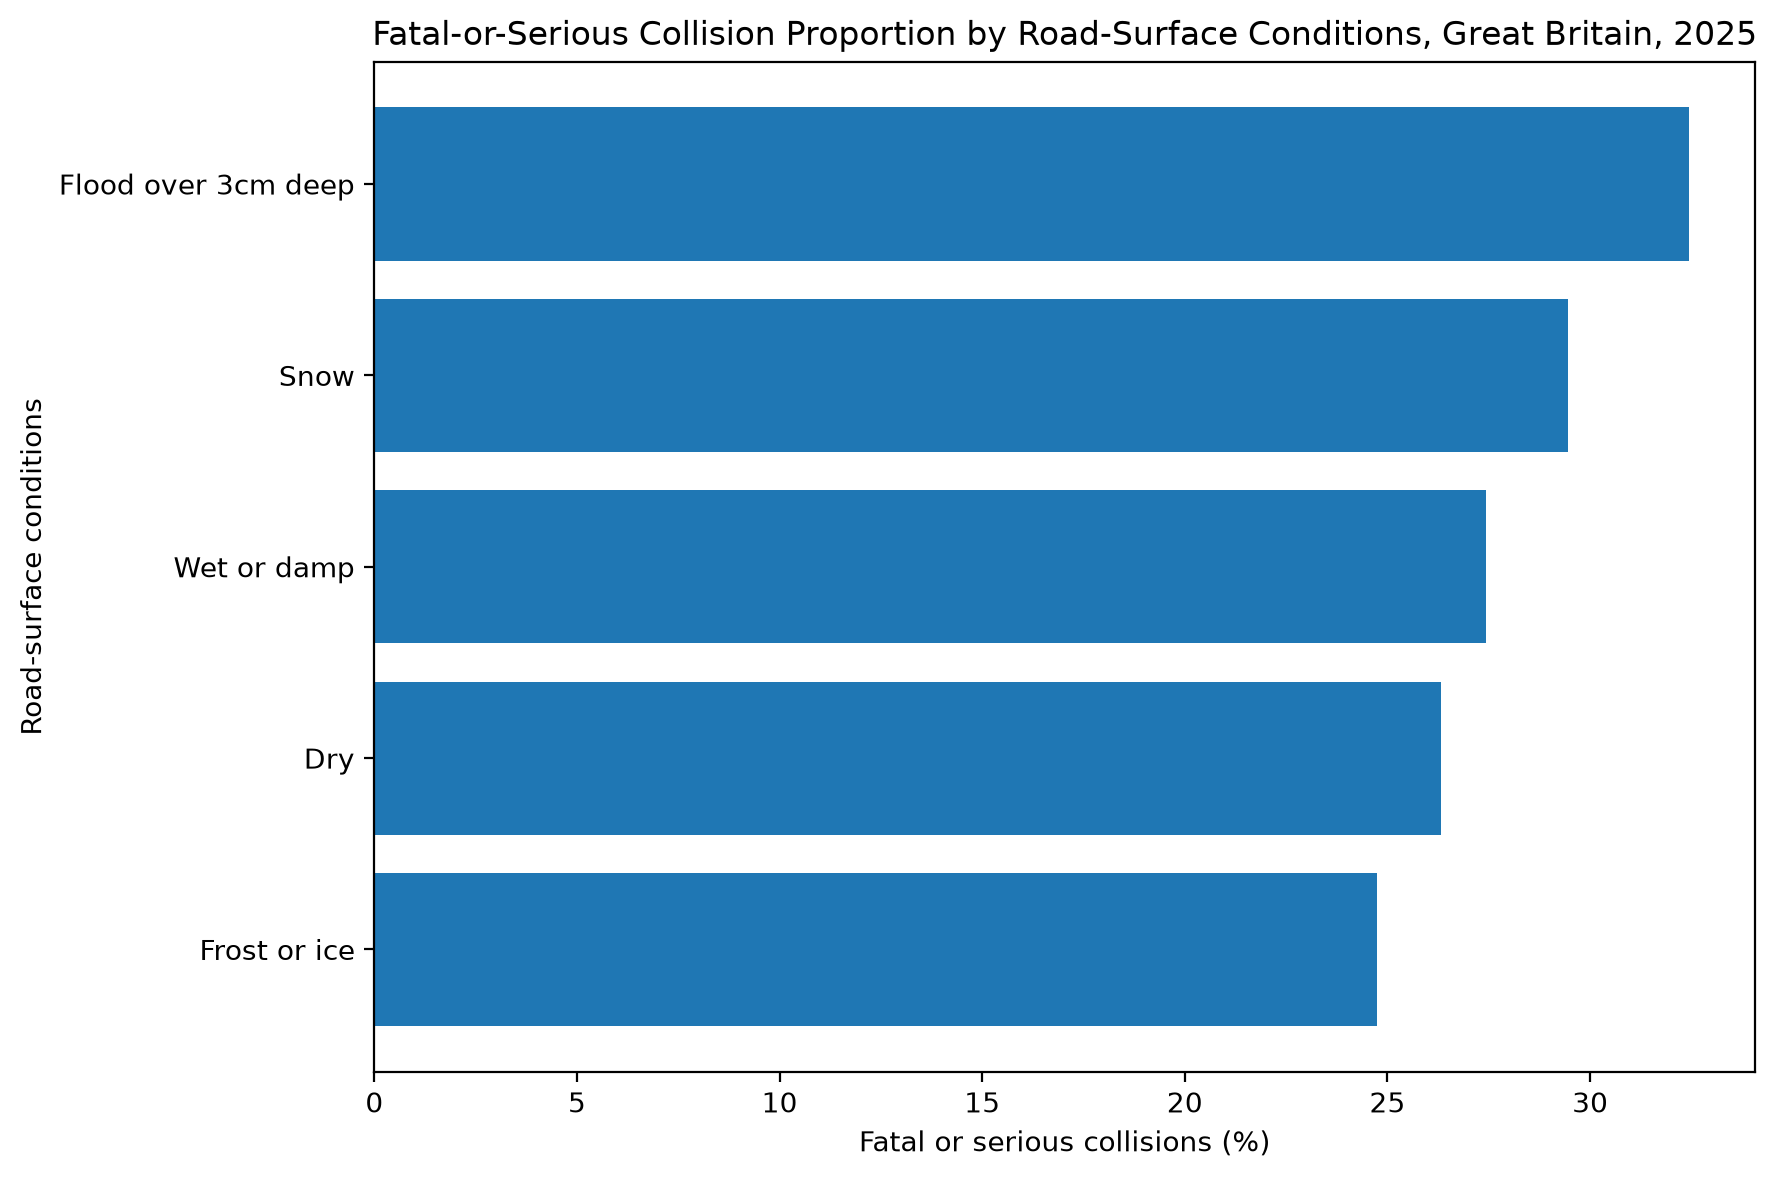

In [435]:
# Visualise the fatal-or-serious collision proportion by road-surface conditions 

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    rq5_surface.index.astype(str),
    rq5_surface["fatal_or_serious_pct"]
)

ax.set_title(
    "Fatal-or-Serious Collision Proportion by Road-Surface Conditions, "
    "Great Britain, 2025"
)
ax.set_xlabel("Fatal or serious collisions (%)")
ax.set_ylabel("Road-surface conditions")

plt.tight_layout()

save_and_show(fig, FIG_DIR / "fatal_serious_by_road_surface_conditions.png")

In [436]:
# Summarise the main environmental-condition contrasts

rq5_summary = pd.DataFrame({
    "Most collisions": [
        rq5_light["total_collisions"].idxmax(),
        rq5_weather["total_collisions"].idxmax(),
        rq5_surface["total_collisions"].idxmax()
    ],
    "Highest fatal-or-serious category": [
        rq5_light["fatal_or_serious_pct"].idxmax(),
        rq5_weather["fatal_or_serious_pct"].idxmax(),
        rq5_surface["fatal_or_serious_pct"].idxmax()
    ],
    "Highest severity (%)": [
        rq5_light["fatal_or_serious_pct"].max(),
        rq5_weather["fatal_or_serious_pct"].max(),
        rq5_surface["fatal_or_serious_pct"].max()
    ],
    "Smallest category n": [
        rq5_light["total_collisions"].min(),
        rq5_weather["total_collisions"].min(),
        rq5_surface["total_collisions"].min()
    ],
    "Largest category n": [
        rq5_light["total_collisions"].max(),
        rq5_weather["total_collisions"].max(),
        rq5_surface["total_collisions"].max()
    ]
}, index=[
    "Light conditions",
    "Weather conditions",
    "Road-surface conditions"
])

display(rq5_summary.round(2))

print(
    "Excluded records — light:",
    f"{len(collisions) - len(rq5_light_data):,}"
)
print(
    "Excluded records — weather:",
    f"{len(collisions) - len(rq5_weather_data):,}"
)
print(
    "Excluded records — road surface:",
    f"{len(collisions) - len(rq5_surface_data):,}"
)

,Most collisions,Highest fatal-or-serious category,Highest severity (%),Smallest category n,Largest category n
Light conditions,Daylight,Darkness - no lighting,36.29,720,72812
Weather conditions,Fine no high winds,Fine + high winds,32.17,19,83404
Road-surface conditions,Dry,Flood over 3cm deep,32.45,146,75678


Excluded records — light: 16
Excluded records — weather: 2,385
Excluded records — road surface: 1,976


## References

Department for Transport (2026a) *Road safety open data*. Available at: https://www.gov.uk/government/statistical-data-sets/road-safety-open-data (Accessed: 5 September 2026).

Department for Transport (2026b) *Reported road casualties Great Britain, final results: 2025*. Available at: https://www.gov.uk/government/statistics/reported-road-casualties-great-britain-final-results-2025 (Accessed: 5 September 2026).

Department for Transport (2025) *Road safety statistics: guidance*. Available at: https://www.gov.uk/guidance/road-accident-and-safety-statistics-guidance (Accessed: 5 September 2026).